In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

S0       = 100.0
sigma0   = 0.46
Y0       = 0.0
rho      = -0.50
gamma    = 0.50
kappa_mr = 1.0
T        = 1.0

n_steps  = 100
dt       = T / n_steps
t_fine   = np.linspace(0, T, n_steps + 1)

n_exercise = 12
exercise_indices = np.round(np.linspace(0, n_steps, n_exercise + 1)).astype(int)
ts_exercise = t_fine[exercise_indices]

N_cal     = 50_000 
N_price   = 100_000
sigma_mkt = 0.15
kappa_bw  = 1.0

K = 100.0

In [2]:
def blackscholes_price(K, T, S, vol, r=0, q=0, callput='call'):
    F = S * np.exp((r - q) * T)
    w = vol**2 * T
    d1 = (np.log(F / K) + 0.5 * w) / np.sqrt(w)
    d2 = d1 - np.sqrt(w)
    opttype = 1 if callput.lower() == 'call' else -1
    price = opttype * (F * norm.cdf(opttype * d1) - K * norm.cdf(opttype * d2)) * np.exp(-r * T)
    return price

def blackscholes_impv_scalar(K, T, S, value, r=0, q=0, callput='call', tol=1e-6, maxiter=500):
    if (K <= 0) or (T <= 0):
        return np.nan
    F = S * np.exp((r - q) * T)
    K_norm = K / F
    value = value * np.exp(r * T) / F
    opttype = 1 if callput.lower() == 'call' else -1
    value -= max(opttype * (1 - K_norm), 0)
    if value < 0:
        return np.nan
    if value == 0:
        return 0
    j = 1
    p = np.log(K_norm)
    if K_norm >= 1:
        x0 = np.sqrt(2 * p)
        x1 = x0 - (0.5 - K_norm * norm.cdf(-x0) - value) * np.sqrt(2 * np.pi)
        while (abs(x0 - x1) > tol * np.sqrt(T)) and (j < maxiter):
            x0 = x1
            d1 = -p / x1 + 0.5 * x1
            x1 = x1 - (norm.cdf(d1) - K_norm * norm.cdf(d1 - x1) - value) * np.sqrt(2 * np.pi) * np.exp(0.5 * d1**2)
            j += 1
    else:
        x0 = np.sqrt(-2 * p)
        x1 = x0 - (0.5 * K_norm - norm.cdf(-x0) - value) * np.sqrt(2 * np.pi) / K_norm
        while (abs(x0 - x1) > tol * np.sqrt(T)) and (j < maxiter):
            x0 = x1
            d1 = -p / x1 + 0.5 * x1
            x1 = x1 - (K_norm * norm.cdf(x1 - d1) - norm.cdf(-d1) - value) * np.sqrt(2 * np.pi) * np.exp(0.5 * d1**2)
            j += 1
    return x1 / np.sqrt(T)

blackscholes_impv = np.vectorize(blackscholes_impv_scalar, excluded={'callput', 'tol', 'maxiter'})

def quartic_kernel(x):
    x = np.clip(x, -1, 1)
    return (x + 1)**2 * (1 - x)**2

In [3]:
put_price = blackscholes_price(95, 0.25, 100, 0.2, r=0.05, callput='put')
print(f"BS Put Price: {put_price:.16f}")
print(f"Expected:     1.5342604771222823")
print(f"Match: {np.isclose(put_price, 1.5342604771222823)}\n")

call_p = blackscholes_price(100, 1.0, 100, 0.2, r=0.05, callput='call')
put_p  = blackscholes_price(100, 1.0, 100, 0.2, r=0.05, callput='put')
print(f"C - P = {call_p - put_p:.6f}")
print(f"S - Ke^(-rT) = {100 - 100*np.exp(-0.05):.6f}\n")

for v in [0.10, 0.15, 0.20, 0.30]:
    cp = blackscholes_price(100, 1.0, 100, v, callput='call')
    iv = blackscholes_impv(100, 1.0, 100, cp, callput='call')
    print(f"Input vol={v:.2f} → price={cp:.6f} → recovered vol={iv:.6f} → error={abs(iv-v):.2e}")

print(f"\nK(-1)={quartic_kernel(np.array([-1.0]))[0]:.4f}, K(0)={quartic_kernel(np.array([0.0]))[0]:.4f}, K(1)={quartic_kernel(np.array([1.0]))[0]:.4f}")
print(f"Symmetric: K(0.3)={quartic_kernel(np.array([0.3]))[0]:.6f}, K(-0.3)={quartic_kernel(np.array([-0.3]))[0]:.6f}")

BS Put Price: 1.5342604771222823
Expected:     1.5342604771222823
Match: True

C - P = 4.877058
S - Ke^(-rT) = 4.877058

Input vol=0.10 → price=3.987761 → recovered vol=0.100000 → error=8.33e-17
Input vol=0.15 → price=5.978529 → recovered vol=0.150000 → error=2.78e-16
Input vol=0.20 → price=7.965567 → recovered vol=0.200000 → error=2.78e-16
Input vol=0.30 → price=11.923538 → recovered vol=0.300000 → error=3.89e-16

K(-1)=0.0000, K(0)=1.0000, K(1)=0.0000
Symmetric: K(0.3)=0.828100, K(-0.3)=0.828100


In [4]:
def quartic_kernel(x):
    x = np.clip(x, -1, 1)
    return (x + 1)**2 * (1 - x)**2


def compute_leverage_on_grid(S_particles, Y_particles, S_grid_k,
                              t_k, sigma0, vol_fn, S0, kappa_bw, N_cal):
    with np.errstate(invalid='ignore', divide='ignore'):
        sigma_grid = vol_fn(S_grid_k, t_k) if callable(vol_fn) else np.full(len(S_grid_k), vol_fn)
        sigma_ref  = float(np.atleast_1d(vol_fn(S0, t_k))[0]) if callable(vol_fn) else float(vol_fn)
        h = kappa_bw * sigma_ref * S0 * np.sqrt(max(t_k, 0.15)) * N_cal**(-0.2)
        u = (S_particles[None, :] - S_grid_k[:, None]) / h
        K_vals = quartic_kernel(u)
        stoch_var = sigma0**2 * np.exp(2 * Y_particles)
        numer = K_vals @ stoch_var
        denom = K_vals.sum(axis=1)
        cond_exp = np.where(denom > 0, numer / denom, sigma0**2)
        lev_grid = np.sqrt(np.clip(sigma_grid**2 / cond_exp, 1e-4, 1e2))
    return lev_grid


def particle_method(S0, sigma0, Y0, rho, gamma, kappa_mr, T,
                    n_steps, N_cal, vol_fn, kappa_bw, n_grid=200, seed=42):
    dt_sim    = T / n_steps
    exp_kdt   = np.exp(-kappa_mr * dt_sim)
    std_Y     = gamma * np.sqrt((1 - np.exp(-2 * kappa_mr * dt_sim)) / (2 * kappa_mr))
    rho_bar   = rho * np.sqrt(2 * (1 - exp_kdt) / (kappa_mr * dt_sim * (1 + exp_kdt)))
    rng       = np.random.default_rng(seed)
    logS      = np.full(N_cal, np.log(S0))
    Y         = np.full(N_cal, float(Y0))
    lev_store = []
    for k in range(n_steps):
        t_k         = k * dt_sim
        S_particles = np.exp(logS)
        Y_old       = Y.copy()
        S_lo = S_particles.min(); S_hi = S_particles.max()
        margin   = 0.05 * (S_hi - S_lo + 1e-8)
        S_grid_k = np.linspace(S_lo - margin, S_hi + margin, n_grid)
        lev_grid = compute_leverage_on_grid(S_particles, Y_old, S_grid_k,
                                             t_k, sigma0, vol_fn, S0, kappa_bw, N_cal)
        lev_store.append((S_grid_k.copy(), lev_grid.copy()))
        lev_p = np.interp(S_particles, S_grid_k, lev_grid)
        Z1 = rng.standard_normal(N_cal); Z2 = rng.standard_normal(N_cal)
        Y    = exp_kdt * Y_old + std_Y * Z2
        veff = sigma0 * np.exp(Y_old) * lev_p
        logS = (logS - 0.5 * veff**2 * dt_sim
                + veff * np.sqrt(dt_sim) * (np.sqrt(1 - rho_bar**2) * Z1 + rho_bar * Z2))
    return lev_store, logS, Y


def slv_paths_matrix(S0, sigma0, Y0, rho, gamma, kappa_mr, T,
                     n_steps, N, lev_store, exercise_indices, seed=0):
    dt_sim  = T / n_steps
    exp_kdt = np.exp(-kappa_mr * dt_sim)
    std_Y   = gamma * np.sqrt((1 - np.exp(-2 * kappa_mr * dt_sim)) / (2 * kappa_mr))
    rho_bar = rho * np.sqrt(2 * (1 - exp_kdt) / (kappa_mr * dt_sim * (1 + exp_kdt)))
    rng     = np.random.default_rng(seed)
    logS    = np.full(N, np.log(S0))
    Y       = np.full(N, float(Y0))
    ex_set  = set(exercise_indices[1:])
    paths   = np.empty((len(exercise_indices), N))
    paths[0] = S0
    Y_paths    = np.empty((len(exercise_indices), N)) 
    Y_paths[0] = Y0                               
    ex_idx  = 1
    for k in range(n_steps):
        S_grid_k, lev_grid_k = lev_store[k]
        S_now = np.exp(logS)
        Y_old = Y.copy()
        lev   = np.interp(S_now, S_grid_k, lev_grid_k)
        Z1 = rng.standard_normal(N); Z2 = rng.standard_normal(N)
        Y    = exp_kdt * Y_old + std_Y * Z2
        veff = sigma0 * np.exp(Y_old) * lev
        logS = (logS - 0.5 * veff**2 * dt_sim
                + veff * np.sqrt(dt_sim) * (np.sqrt(1 - rho_bar**2) * Z1 + rho_bar * Z2))
        if (k + 1) in ex_set:
            paths[ex_idx]   = np.exp(logS)
            Y_paths[ex_idx] = Y      
            ex_idx += 1
    return paths, Y_paths                 


def regression_polynomial(X, Y, S_current, degree=3, **kwargs):
    coeffs = np.polyfit(X, Y, deg=degree)
    return np.polyval(coeffs, S_current), {'type': 'polynomial', 'coeffs': coeffs, 'degree': degree}


def ls_pricer(paths, K, r, ts, regression_func, **regression_params):
    n_steps, n_paths = paths.shape
    payoff = np.maximum(K - paths[-1], 0)
    exercise_policy = {'models': [], 'ts': ts, 'K': K, 'r': r}
    for i in range(n_steps - 2, 0, -1):
        discount          = np.exp(-r * (ts[i + 1] - ts[i]))
        payoff_discounted = payoff * discount
        exercise_value    = np.maximum(K - paths[i], 0)
        X = paths[i]; Y_reg = payoff_discounted
        tau = ts[-1] - ts[i]
        cont_value, model = regression_func(X, Y_reg, X, K=K, r=r, tau=tau, **regression_params)
        exercise_policy['models'].insert(0, model)
        exercise_mask = exercise_value > cont_value
        payoff_new = payoff_discounted.copy()
        payoff_new[exercise_mask] = exercise_value[exercise_mask]
        payoff = payoff_new
    price = np.mean(payoff * np.exp(-r * (ts[1] - ts[0])))
    return price, exercise_policy


def exer_or_cont(i, S, models, K, r, ts):
    S = np.atleast_1d(S)
    if i >= len(ts) - 1:
        return np.maximum(K - S, 0) > 0
    if i < 1 or i - 1 >= len(models):
        return np.zeros(len(S), dtype=bool)
    model = models[i - 1]
    exercise_value = np.maximum(K - S, 0)
    cont_value = np.polyval(model['coeffs'], S)
    return exercise_value > cont_value


def nested_mc(S, Y_start, lev_store, exercise_indices,
              sigma0, rho, gamma, kappa_mr,
              r, q, i, ts, nnested, models, K, dt_fine,
              seed=None):
    nested_S = np.full(nnested, float(S))
    nested_Y = np.full(nnested, float(Y_start))
    tot_payoff = 0.0
    exp_kdt = np.exp(-kappa_mr * dt_fine)
    std_Y   = gamma * np.sqrt((1 - np.exp(-2 * kappa_mr * dt_fine)) / (2 * kappa_mr))
    rho_bar = rho * np.sqrt(2 * (1 - exp_kdt) / (kappa_mr * dt_fine * (1 + exp_kdt)))
    rng     = np.random.default_rng(seed)
    for j in range(i + 1, len(ts)):
        step_start = exercise_indices[j - 1]
        step_end   = exercise_indices[j]
        for step_k in range(step_start, step_end):
            S_grid, lev_grid = lev_store[step_k]
            lev    = np.interp(nested_S, S_grid, lev_grid)
            Z1     = rng.standard_normal(len(nested_S))
            Z2     = rng.standard_normal(len(nested_S))
            Y_old  = nested_Y.copy()
            nested_Y = exp_kdt * Y_old + std_Y * Z2
            veff   = sigma0 * np.exp(Y_old) * lev
            nested_S = nested_S * np.exp(
                (r - q) * dt_fine - 0.5 * veff**2 * dt_fine
                + veff * np.sqrt(dt_fine) * (np.sqrt(1 - rho_bar**2) * Z1 + rho_bar * Z2)
            )
        exer_vals = np.maximum(K - nested_S, 0)
        if j < len(ts) - 1:
            ind = exer_or_cont(j, nested_S, models, K, r, ts)
            tot_payoff += np.sum(exer_vals[ind]) * np.exp(-r * ts[j])
            nested_S = nested_S[~ind]
            nested_Y = nested_Y[~ind]
            if len(nested_S) == 0:
                break
        else:
            tot_payoff += np.sum(exer_vals) * np.exp(-r * ts[j])
    return tot_payoff / nnested

r = 0.0
q = 0.0

lev_store, _, _ = particle_method(S0, sigma0, Y0, rho, gamma, kappa_mr, T,
                                   n_steps, N_cal, sigma_mkt, kappa_bw)

paths_train, Y_paths_train = slv_paths_matrix(S0, sigma0, Y0, rho, gamma, kappa_mr, T,
                                               n_steps, N_cal, lev_store, exercise_indices, seed=42)

price_lsm_slv, policy_slv = ls_pricer(paths_train, K, r, ts_exercise,
                                        regression_polynomial, degree=3)
models_slv = policy_slv['models']

N_ba     = 500
N_nested = 1000
paths_ba, Y_paths_ba = slv_paths_matrix(S0, sigma0, Y0, rho, gamma, kappa_mr, T,
                                         n_steps, N_ba, lev_store, exercise_indices, seed=777)

exer_slv = lambda S: np.maximum(K - S, 0)

V  = np.full(paths_ba.shape, np.nan)
EV = np.full(paths_ba.shape, np.nan)
V[0] = EV[0] = price_lsm_slv

for i in range(1, len(ts_exercise) - 1):
    ev  = exer_slv(paths_ba[i])
    ind = exer_or_cont(i, paths_ba[i], models_slv, K, r, ts_exercise)
    for j in np.nonzero(ind)[0]:
        V[i, j]  = ev[j] * np.exp(-r * ts_exercise[i])
        EV[i, j] = nested_mc(paths_ba[i, j], Y_paths_ba[i, j], lev_store, exercise_indices,
                              sigma0, rho, gamma, kappa_mr,
                              r, q, i, ts_exercise, N_nested, models_slv, K, dt)
    for j in np.nonzero(~ind)[0]:
        V[i, j]  = nested_mc(paths_ba[i, j], Y_paths_ba[i, j], lev_store, exercise_indices,
                              sigma0, rho, gamma, kappa_mr,
                              r, q, i, ts_exercise, N_nested, models_slv, K, dt)
        EV[i, j] = V[i, j]

V[-1]      = exer_slv(paths_ba[-1]) * np.exp(-r * ts_exercise[-1])
hedges     = np.zeros(paths_ba.shape)
hedges[1:] = np.cumsum(V[1:] - EV[:-1], axis=0)

upper_slv = np.mean(np.amax(
    exer_slv(paths_ba[1:]) * np.exp(-r * ts_exercise[1:, np.newaxis]) - hedges[1:],
    axis=0
))

print(f"SLV American Put  (K={K}, T={T}, r={r})")
print(f"  LSM Lower : {price_lsm_slv:.4f}")
print(f"  BA  Upper : {upper_slv:.4f}")

SLV American Put  (K=100.0, T=1.0, r=0.0)
  LSM Lower : 5.7998
  BA  Upper : 6.0115


In [5]:
r = 0.0

K_list = np.array([70, 80, 90, 100, 110, 120, 130, 140], dtype=float)

def _impv(K_, price, callput='call'):
    from scipy.optimize import brentq
    def obj(v):
        sqT = np.sqrt(T)
        d1 = np.log(S0/K_)/(v*sqT) + 0.5*v*sqT
        d2 = d1 - v*sqT
        if callput == 'call':
            return S0*norm.cdf(d1) - K_*norm.cdf(d2) - price
        else:
            return K_*norm.cdf(-d2) - S0*norm.cdf(-d1) - price
    try:
        return brentq(obj, 1e-6, 5.0)
    except:
        return np.nan

def bs_european_put(K_, T_, S_, v_):
    sqT = np.sqrt(T_)
    d1  = np.log(S_/K_)/(v_*sqT) + 0.5*v_*sqT
    d2  = d1 - v_*sqT
    return K_*norm.cdf(-d2) - S_*norm.cdf(-d1)

print("=" * 60)
print("1. quartic_kernel")
print("=" * 60)
assert quartic_kernel(np.array([-1.0]))[0] == 0.0
assert quartic_kernel(np.array([ 1.0]))[0] == 0.0
assert quartic_kernel(np.array([ 0.0]))[0] == 1.0
assert np.isclose(quartic_kernel(np.array([0.3]))[0],
                  quartic_kernel(np.array([-0.3]))[0])
print("  PASS — boundary, peak, symmetry")

print()
print("=" * 60)
print("2. particle_method — smile calibration check")
print("=" * 60)
_lev_store, _logS_cal, _ = particle_method(S0, sigma0, Y0, rho, gamma, kappa_mr, T,
                                             n_steps, N_cal, sigma_mkt, kappa_bw)
S_T_check = np.exp(_logS_cal)
call_p = np.array([np.maximum(S_T_check - K_, 0).mean() for K_ in K_list])
put_p  = np.array([np.maximum(K_ - S_T_check, 0).mean() for K_ in K_list])
ivs = np.where(K_list < S0,
               [_impv(K_, p, 'put')  for K_, p in zip(K_list, put_p)],
               [_impv(K_, p, 'call') for K_, p in zip(K_list, call_p)])
max_err = np.nanmax(np.abs(ivs - sigma_mkt))
print(f"  {'Strike':>8}  {'IV':>8}  {'Error':>10}")
for K_, iv in zip(K_list, ivs):
    print(f"  {K_:>8.0f}  {iv:>8.4f}  {abs(iv-sigma_mkt):>10.4f}")
_cal_pass = max_err < 0.01
print(f"  Max error: {max_err:.4f}  {'PASS' if _cal_pass else 'FAIL'}")

print()
print("=" * 60)
print("3. slv_paths_matrix — shape & basic sanity")
print("=" * 60)
_paths, _Y_paths = slv_paths_matrix(S0, sigma0, Y0, rho, gamma, kappa_mr, T,
                                     n_steps, 5000, _lev_store, exercise_indices, seed=0)
assert _paths.shape == (len(exercise_indices), 5000)
assert np.all(_paths[0] == S0)
assert not np.any(np.isnan(_paths))
assert np.all(_paths > 0)
_mean_err = abs(_paths[-1].mean() - S0)
print(f"  shape : {_paths.shape}  PASS")
print(f"  t=0   : all == {S0}  PASS")
print(f"  NaN   : none  PASS")
print(f"  S_T   : mean={_paths[-1].mean():.2f}  std={_paths[-1].std():.2f}")
_path_pass = _mean_err < 3.0
print(f"  E[S_T] error vs S0: {_mean_err:.4f}  {'PASS' if _path_pass else 'FAIL'}")

print()
print("=" * 60)
print("4. ls_pricer — lower bound sanity (r=0: American ≈ European)")
print("=" * 60)
_price_lsm, _policy = ls_pricer(_paths, K, r, ts_exercise, regression_polynomial, degree=3)
_bs_eur = bs_european_put(K, T, S0, sigma_mkt)
_premium = _price_lsm - _bs_eur
print(f"  LSM Lower  : {_price_lsm:.4f}")
print(f"  BS European: {_bs_eur:.4f}")
print(f"  Difference : {_premium:.4f}")
print(f"  Note: r=0 so early exercise is suboptimal → |diff| driven by MC noise")
_lsm_pass = abs(_premium) < 0.5
print(f"  |diff| < 0.5 : {'PASS' if _lsm_pass else 'FAIL'}")
assert len(_policy['models']) == len(ts_exercise) - 2
print(f"  # models   : {len(_policy['models'])} (expected {len(ts_exercise)-2})  PASS")

print()
print("=" * 60)
print("5. exer_or_cont — boundary conditions")
print("=" * 60)
_models = _policy['models']
_deep_otm = np.array([150.0, 160.0])
_exer_otm = exer_or_cont(1, _deep_otm, _models, K, r, ts_exercise)
_exer_mat_itm = exer_or_cont(len(ts_exercise)-1, np.array([50.0, 60.0]), _models, K, r, ts_exercise)
_exer_mat_otm = exer_or_cont(len(ts_exercise)-1, np.array([150.0, 160.0]), _models, K, r, ts_exercise)
_otm_pass = not any(_exer_otm)
_mat_itm_pass = all(_exer_mat_itm)
_mat_otm_pass = not any(_exer_mat_otm)
print(f"  Deep OTM at t=1 → no exercise  : {_exer_otm}  {'PASS' if _otm_pass else 'FAIL'}")
print(f"  At maturity ITM → exercise      : {_exer_mat_itm}  {'PASS' if _mat_itm_pass else 'FAIL'}")
print(f"  At maturity OTM → no exercise   : {_exer_mat_otm}  {'PASS' if _mat_otm_pass else 'FAIL'}")

print()
print("=" * 60)
print("6. BA upper bound — valid sandwich")
print("=" * 60)
print(f"  LSM Lower : {price_lsm_slv:.4f}")
print(f"  BA  Upper : {upper_slv:.4f}")
print(f"  Gap       : {upper_slv - price_lsm_slv:.4f}")
_ba_pass = price_lsm_slv < upper_slv
print(f"  Lower < Upper : {'PASS' if _ba_pass else 'FAIL'}")

print()
print("=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"  quartic_kernel     : PASS")
print(f"  particle_method    : {'PASS' if _cal_pass else 'FAIL'}")
print(f"  slv_paths_matrix   : {'PASS' if _path_pass else 'FAIL'}")
print(f"  ls_pricer          : {'PASS' if _lsm_pass else 'FAIL'}")
print(f"  exer_or_cont       : {'PASS' if _otm_pass and _mat_itm_pass and _mat_otm_pass else 'FAIL'}")
print(f"  BA upper bound     : {'PASS' if _ba_pass else 'FAIL'}")

1. quartic_kernel
  PASS — boundary, peak, symmetry

2. particle_method — smile calibration check
    Strike        IV       Error
        70    0.1493      0.0007
        80    0.1502      0.0002
        90    0.1503      0.0003
       100    0.1490      0.0010
       110    0.1490      0.0010
       120    0.1496      0.0004
       130    0.1496      0.0004
       140    0.1487      0.0013
  Max error: 0.0013  PASS

3. slv_paths_matrix — shape & basic sanity
  shape : (13, 5000)  PASS
  t=0   : all == 100.0  PASS
  NaN   : none  PASS
  S_T   : mean=100.31  std=14.96
  E[S_T] error vs S0: 0.3054  PASS

4. ls_pricer — lower bound sanity (r=0: American ≈ European)
  LSM Lower  : 5.6585
  BS European: 5.9785
  Difference : -0.3200
  Note: r=0 so early exercise is suboptimal → |diff| driven by MC noise
  |diff| < 0.5 : PASS
  # models   : 11 (expected 11)  PASS

5. exer_or_cont — boundary conditions
  Deep OTM at t=1 → no exercise  : [False False]  PASS
  At maturity ITM → exercise      :

In [6]:
import openpyxl
from datetime import datetime

wb = openpyxl.load_workbook('sample_data.xlsx')
ws   = wb['NVDA Options']
S0_nvda = 183.34

expiries = []
current  = None

for row in ws.iter_rows(values_only=True):
    if row[0] == 'Strike':
        continue
    if isinstance(row[0], str) and 'CSize' in row[0]:
        header = row[0]
        days   = int(header.split('(')[1].split('d')[0])
        T_exp  = days / 365.0
        R      = float(header.split('R ')[1].split(';')[0]) / 100.0
        IFwd   = float(header.split('IFwd ')[1].replace(')', '').strip())
        current = {'T': T_exp, 'R': R, 'IFwd': IFwd, 'strikes': [], 'ivs': [], 'vols': []}
        expiries.append(current)
    elif current is not None and isinstance(row[0], (int, float)):
        K_    = float(row[0])
        iv_c  = float(row[5]) / 100.0
        iv_p  = float(row[12]) / 100.0
        vol_c = float(row[6]) if row[6] else 0
        vol_p = float(row[13]) if row[13] else 0
        iv_mid = (iv_c * vol_c + iv_p * vol_p) / (vol_c + vol_p) if (vol_c + vol_p) > 0 else (iv_c + iv_p) / 2
        total_vol = vol_c + vol_p
        current['strikes'].append(K_)
        current['ivs'].append(iv_mid)
        current['vols'].append(total_vol)

for i, exp in enumerate(expiries):
    print(f"T={exp['T']:.4f} ({int(exp['T']*365)}d) R={exp['R']:.4f} IFwd={exp['IFwd']:.2f} | "
          f"strikes={exp['strikes']} | total_vol={sum(exp['vols'])}")

T=0.0411 (15d) R=0.0394 IFwd=182.65 | strikes=[177.5, 180.0, 182.5, 185.0, 187.5] | total_vol=60253.0
T=0.1178 (43d) R=0.0394 IFwd=183.17 | strikes=[175.0, 180.0, 185.0, 190.0, 195.0] | total_vol=30441.0
T=0.1945 (71d) R=0.0394 IFwd=183.69 | strikes=[175.0, 180.0, 185.0, 190.0, 195.0] | total_vol=38226.0
T=0.2877 (105d) R=0.0394 IFwd=184.32 | strikes=[181.0, 182.0, 183.0, 184.0, 185.0] | total_vol=2599.0
T=0.3671 (134d) R=0.0393 IFwd=184.85 | strikes=[175.0, 180.0, 185.0, 190.0, 195.0] | total_vol=4276.0
T=0.4630 (169d) R=0.0392 IFwd=185.49 | strikes=[175.0, 180.0, 185.0, 190.0, 195.0] | total_vol=5682.0
T=0.5397 (197d) R=0.0390 IFwd=186.00 | strikes=[175.0, 180.0, 185.0, 190.0, 195.0] | total_vol=3468.0
T=0.7123 (260d) R=0.0386 IFwd=187.12 | strikes=[175.0, 180.0, 185.0, 190.0, 195.0] | total_vol=1532.0
T=0.7890 (288d) R=0.0384 IFwd=187.61 | strikes=[181.0, 182.0, 183.0, 184.0, 185.0] | total_vol=1165.0
T=0.8658 (316d) R=0.0382 IFwd=188.09 | strikes=[175.0, 180.0, 185.0, 190.0, 195.0]

# Sam edit: Heston Calibration (to fix nonsmooth model IV)

### Heston Characteristic Function & Vectorised Pricing

In [7]:
def heston_char_func(u, j, T, S0, r, q, v0, kappa, theta, xi, rho):
    """
    Heston characteristic function φ_j(u) for j ∈ {1, 2}.
    'Little Heston Trap' formulation (Albrecher et al. 2007) —
    ensures |g| < 1 so that g·e^{-dT} decays and the log stays real.
    Vectorised over u (1-D complex array).
    """
    u = np.asarray(u, dtype=np.complex128)

    bj = (kappa - rho * xi) if j == 1 else kappa
    uj = 0.5 if j == 1 else -0.5

    alpha = bj - rho * xi * 1j * u
    d     = np.sqrt(alpha**2 + xi**2 * (u**2 - 2.0 * uj * 1j * u))

    g       = (alpha - d) / (alpha + d)
    exp_mdt = np.exp(-d * T)

    D_val = ((alpha - d) / xi**2) * (1.0 - exp_mdt) / (1.0 - g * exp_mdt)
    C_val = (1j * u * (np.log(S0) + (r - q) * T)
             + (kappa * theta / xi**2)
               * ((alpha - d) * T
                  - 2.0 * np.log((1.0 - g * exp_mdt) / (1.0 - g))))

    return np.exp(C_val + D_val * v0)


def heston_call_grid(S0, K_arr, T, r, q, v0, kappa, theta, xi, rho,
                     n_quad=256):
    """
    European call prices for a *vector* of strikes at a single expiry.
    Uses Gauss–Legendre quadrature on [ε, u_max].
    """
    K_arr = np.atleast_1d(np.asarray(K_arr, dtype=float))
    if T < 1e-10:
        return np.maximum(S0 * np.exp(-q * T) - K_arr, 0.0)

    eps   = 1e-8
    u_max = 300.0
    nodes, weights = np.polynomial.legendre.leggauss(n_quad)
    u = (nodes + 1.0) / 2.0 * (u_max - eps) + eps     # (n_quad,)
    w = weights * (u_max - eps) / 2.0                   # (n_quad,)

    cf1 = heston_char_func(u, 1, T, S0, r, q, v0, kappa, theta, xi, rho)
    cf2 = heston_char_func(u, 2, T, S0, r, q, v0, kappa, theta, xi, rho)

    logK   = np.log(K_arr)                              # (n_K,)
    phase  = np.exp(-1j * u[None, :] * logK[:, None])   # (n_K, n_quad)
    inv_iu = 1.0 / (1j * u[None, :])                    # (1, n_quad)

    P1 = 0.5 + np.dot(np.real(phase * cf1[None, :] * inv_iu), w) / np.pi
    P2 = 0.5 + np.dot(np.real(phase * cf2[None, :] * inv_iu), w) / np.pi

    return np.maximum(S0 * np.exp(-q * T) * P1
                      - K_arr * np.exp(-r * T) * P2, 0.0)


# ——— quick sanity checks ———
_test_v0 = 0.04
_pc = heston_call_grid(100, np.array([100.0]), 1.0, 0.05, 0.0,
                        _test_v0, 2.0, _test_v0, 1e-6, -0.5)[0]
_pb = blackscholes_price(100, 1.0, 100, np.sqrt(_test_v0), r=0.05, callput='call')
print(f"Heston (ξ→0) = {_pc:.6f}  |  BS = {_pb:.6f}  |  match = {np.isclose(_pc, _pb, atol=0.01)}")

_c = heston_call_grid(100, np.array([90.0, 100.0, 110.0]), 1.0, 0.05, 0.0,
                       0.04, 2.0, 0.04, 0.5, -0.7)
for _K, _p in zip([90, 100, 110], _c):
    _iv = blackscholes_impv_scalar(_K, 1.0, 100, float(_p), r=0.05, callput='call')
    print(f"  K={_K}  price={_p:.6f}  IV={_iv:.4f}")

Heston (ξ→0) = 10.450455  |  BS = 10.450584  |  match = True
  K=90  price=17.140055  IV=0.2159
  K=100  price=10.154627  IV=0.1921
  K=110  price=4.866183  IV=0.1702


### Heston Calibration to Market IVs

In [8]:
from scipy.optimize import differential_evolution

"1st attempt: run too slow"
# def calibrate_heston(expiries, S0, n_quad=128):
#     """
#     Global calibration of the 5 Heston parameters to all market IVs.
#     Uses differential evolution → L-BFGS-B polish.
#     n_quad=128 during search (fast); final reporting uses 256.
#     """
#     # ---- collect data, one group per expiry ----
#     groups  = []
#     n_total = 0
#     for exp in expiries:
#         T = exp['T'];  r = exp['R'];  F = exp['IFwd']
#         q = r - np.log(F / S0) / T if T > 1e-8 else 0.0
#         groups.append(dict(T=T, r=r, q=q,
#                            K=np.array(exp['strikes'], dtype=float),
#                            iv=np.array(exp['ivs'],     dtype=float)))
#         n_total += len(exp['strikes'])

#     def objective(params):
#         v0, kappa, theta, xi, rho = params
#         err = 0.0
#         for g in groups:
#             try:
#                 prices = heston_call_grid(S0, g['K'], g['T'], g['r'], g['q'],
#                                           v0, kappa, theta, xi, rho,
#                                           n_quad=n_quad)
#                 for K, price, iv_mkt in zip(g['K'], prices, g['iv']):
#                     iv_mod = blackscholes_impv_scalar(
#                         K, g['T'], S0, float(price),
#                         r=g['r'], q=g['q'], callput='call')
#                     if np.isnan(iv_mod) or iv_mod <= 0:
#                         return 1e6
#                     err += (iv_mod - iv_mkt) ** 2
#             except Exception:
#                 return 1e6
#         return err / n_total

#     bounds = [
#         (0.01,  1.0),   # v0
#         (0.01, 15.0),   # kappa
#         (0.01,  1.0),   # theta
#         (0.01,  4.0),   # xi
#         (-0.99, 0.99),  # rho
#     ]

#     print("Calibrating Heston (differential evolution) …")
#     result = differential_evolution(
#         objective, bounds, seed=42,
#         maxiter=300, tol=1e-10, polish=True,
#         mutation=(0.5, 1.5), recombination=0.9, popsize=20)

#     v0, kappa, theta, xi, rho = result.x
#     rmse = np.sqrt(result.fun)

#     print(f"\n{'='*60}")
#     print("Heston calibration results")
#     print(f"{'='*60}")
#     print(f"  v0    = {v0:.6f}   (σ₀ = {np.sqrt(v0):.4f})")
#     print(f"  κ     = {kappa:.4f}")
#     print(f"  θ     = {theta:.6f}   (σ_∞ = {np.sqrt(theta):.4f})")
#     print(f"  ξ     = {xi:.4f}")
#     print(f"  ρ     = {rho:.4f}")
#     print(f"  RMSE  = {rmse:.6f}")
#     print(f"  Feller: 2κθ = {2*kappa*theta:.4f}  vs  ξ² = {xi**2:.4f}  "
#           f"({'OK' if 2*kappa*theta > xi**2 else 'VIOLATED'})")

#     # ---- per-strike report (full precision quadrature) ----
#     print()
#     for g in groups:
#         prices = heston_call_grid(S0, g['K'], g['T'], g['r'], g['q'],
#                                   v0, kappa, theta, xi, rho, n_quad=256)
#         print(f"  T = {g['T']:.4f}  ({int(g['T']*365)}d)   r = {g['r']:.4f}")
#         for K, price, iv_mkt in zip(g['K'], prices, g['iv']):
#             iv_mod = blackscholes_impv_scalar(
#                 K, g['T'], S0, float(price),
#                 r=g['r'], q=g['q'], callput='call')
#             tag = '✓' if abs(iv_mod - iv_mkt) < 0.005 else '✗'
#             print(f"    K={K:>7.1f}  mkt={iv_mkt:.4f}  "
#                   f"mod={iv_mod:.4f}  err={abs(iv_mod-iv_mkt):.5f}  {tag}")

#     return result.x


# heston_params = calibrate_heston(expiries, S0_nvda)

""" 
    2nd attempt: run faster (2.5 mins)
"""
def calibrate_heston(expiries, S0, n_quad=128):
    groups  = []
    n_total = 0
    for exp in expiries:
        T = exp['T'];  r = exp['R'];  F = exp['IFwd']
        # focus only on short term < 100d
        if T * 365 >= 100:
            continue
        q = r - np.log(F / S0) / T if T > 1e-8 else 0.0
        K_arr  = np.array(exp['strikes'], dtype=float)
        iv_arr = np.array(exp['ivs'],     dtype=float)
        # pre-compute market prices and vegas for weighting
        mkt_prices = np.array([
            blackscholes_price(K, T, S0, iv, r=r, q=q, callput='call')
            for K, iv in zip(K_arr, iv_arr)])
        vegas = np.array([
            S0 * np.sqrt(T) * np.exp(-0.5 * (
                (np.log(S0/K) + (r - q + 0.5*iv**2)*T) / (iv*np.sqrt(T))
            )**2) / np.sqrt(2*np.pi)
            for K, iv in zip(K_arr, iv_arr)])
        vegas = np.maximum(vegas, 1e-6)
        groups.append(dict(T=T, r=r, q=q, K=K_arr,
                           mkt_prices=mkt_prices, vegas=vegas))
        n_total += len(K_arr)

    def objective(params):
        v0, kappa, theta, xi, rho = params
        err = 0.0
        for g in groups:
            try:
                prices = heston_call_grid(S0, g['K'], g['T'], g['r'], g['q'],
                                          v0, kappa, theta, xi, rho,
                                          n_quad=n_quad)
                # vega-weighted price error ≈ IV error squared
                err += np.sum(((prices - g['mkt_prices']) / g['vegas'])**2)
            except Exception:
                return 1e6
        return err / n_total

    bounds = [
        (0.01,  1.0),   # v0
        (0.01, 15.0),   # kappa
        (0.01,  1.0),   # theta
        (0.01,  4.0),   # xi
        (-0.99, 0.99),  # rho
    ]

    print("Calibrating Heston (differential evolution) …")
    result = differential_evolution(
        objective, bounds, seed=42,
        maxiter=150, tol=1e-8, polish=True,
        mutation=(0.5, 1.5), recombination=0.9, popsize=10)

    v0, kappa, theta, xi, rho = result.x
    rmse = np.sqrt(result.fun)

    print(f"\n{'='*60}")
    print("Heston calibration results")
    print(f"{'='*60}")
    print(f"  v0    = {v0:.6f}   (σ₀ = {np.sqrt(v0):.4f})")
    print(f"  κ     = {kappa:.4f}")
    print(f"  θ     = {theta:.6f}   (σ_∞ = {np.sqrt(theta):.4f})")
    print(f"  ξ     = {xi:.4f}")
    print(f"  ρ     = {rho:.4f}")
    print(f"  RMSE(IV-equiv) ≈ {rmse:.6f}")
    print(f"  Feller: 2κθ = {2*kappa*theta:.4f}  vs  ξ² = {xi**2:.4f}  "
          f"({'OK' if 2*kappa*theta > xi**2 else 'VIOLATED'})")

    # ---- per-strike report ----
    print()
    for exp in expiries:
        T = exp['T'];  r = exp['R'];  F = exp['IFwd']
        # focus only on short term < 100d
        if T * 365 >= 100:
            continue
        q = r - np.log(F / S0) / T if T > 1e-8 else 0.0
        K_arr = np.array(exp['strikes'])
        prices = heston_call_grid(S0, K_arr, T, r, q,
                                  v0, kappa, theta, xi, rho, n_quad=256)
        print(f"  T = {T:.4f}  ({int(T*365)}d)   r = {r:.4f}")
        for K, price, iv_mkt in zip(K_arr, prices, exp['ivs']):
            iv_mod = blackscholes_impv_scalar(
                K, T, S0, float(price), r=r, q=q, callput='call')
            tag = '✓' if abs(iv_mod - iv_mkt) < 0.005 else '✗'
            print(f"    K={K:>7.1f}  mkt={iv_mkt:.4f}  "
                  f"mod={iv_mod:.4f}  err={abs(iv_mod-iv_mkt):.5f}  {tag}")

    return result.x


heston_params = calibrate_heston(expiries, S0_nvda)

""" 
    3rd attempt: piecewise-constant theta
"""
# def calibrate_heston(expiries, S0, n_quad=128):
#     """Heston calibration with piecewise-constant theta per expiry."""
#     n_exp = len(expiries)

#     # ---- pre-compute market prices & vegas ----
#     groups = []
#     n_total = 0
#     for exp in expiries:
#         T = exp['T']; r = exp['R']; F = exp['IFwd']
#         q = r - np.log(F / S0) / T if T > 1e-8 else 0.0
#         K_arr  = np.array(exp['strikes'], dtype=float)
#         iv_arr = np.array(exp['ivs'],     dtype=float)
#         mkt_prices = np.array([
#             blackscholes_price(K, T, S0, iv, r=r, q=q, callput='call')
#             for K, iv in zip(K_arr, iv_arr)])
#         vegas = np.array([
#             S0 * np.sqrt(T) * np.exp(-0.5 * (
#                 (np.log(S0/K) + (r - q + 0.5*iv**2)*T) / (iv*np.sqrt(T))
#             )**2) / np.sqrt(2*np.pi)
#             for K, iv in zip(K_arr, iv_arr)])
#         vegas = np.maximum(vegas, 1e-6)
#         groups.append(dict(T=T, r=r, q=q, K=K_arr,
#                            mkt_prices=mkt_prices, vegas=vegas, ivs=iv_arr))
#         n_total += len(K_arr)

#     # ---- objective with per-expiry theta ----
#     def objective(params):
#         v0    = params[0]
#         xi    = params[1]
#         rho   = params[2]
#         kappa = params[3]
#         thetas = params[4: 4 + n_exp]

#         err = 0.0
#         for i, g in enumerate(groups):
#             try:
#                 prices = heston_call_grid(S0, g['K'], g['T'], g['r'], g['q'],
#                                           v0, kappa, thetas[i], xi, rho,
#                                           n_quad=n_quad)
#                 err += np.sum(((prices - g['mkt_prices']) / g['vegas'])**2)
#             except Exception:
#                 return 1e6
#         return err / n_total

#     # ---- bounds: v0, xi, rho, kappa, then one theta per expiry ----
#     bounds = (
#         [(0.01, 1.0),          # v0
#          (0.05, 4.0),          # xi
#          (-0.99, 0.01),        # rho  (negative for equities)
#          (0.1, 15.0)]          # kappa
#         + [(0.01, 1.0)] * n_exp  # theta_i
#     )

#     print(f"Calibrating Heston with {n_exp} piecewise thetas …")
#     result = differential_evolution(
#         objective, bounds, seed=42,
#         maxiter=200, tol=1e-9, polish=True,
#         mutation=(0.5, 1.5), recombination=0.9, popsize=15)

#     v0, xi, rho, kappa = result.x[:4]
#     thetas = result.x[4: 4 + n_exp]

#     # ---- print results ----
#     print(f"\n{'='*60}")
#     print("Heston piecewise-θ calibration results")
#     print(f"{'='*60}")
#     print(f"  v0    = {v0:.6f}   (σ₀ = {np.sqrt(v0):.4f})")
#     print(f"  κ     = {kappa:.4f}")
#     print(f"  ξ     = {xi:.4f}")
#     print(f"  ρ     = {rho:.4f}")
#     print()
#     for i, (g, exp) in enumerate(zip(groups, expiries)):
#         T = g['T']
#         th = thetas[i]
#         feller = 2 * kappa * th > xi**2
#         print(f"  T={T:.4f} ({int(T*365):>3d}d)  θ={th:.6f}  "
#               f"σ∞={np.sqrt(th):.4f}  Feller={'OK' if feller else 'FAIL'}")

#     rmse = np.sqrt(result.fun)
#     print(f"\n  RMSE(IV-equiv) ≈ {rmse:.6f}")

#     # ---- per-strike report ----
#     print()
#     for i, (g, exp) in enumerate(zip(groups, expiries)):
#         prices = heston_call_grid(S0, g['K'], g['T'], g['r'], g['q'],
#                                   v0, kappa, thetas[i], xi, rho, n_quad=256)
#         print(f"  T = {g['T']:.4f}  ({int(g['T']*365)}d)")
#         for K, price, iv_mkt in zip(g['K'], prices, g['ivs']):
#             iv_mod = blackscholes_impv_scalar(
#                 K, g['T'], S0, float(price), r=g['r'], q=g['q'], callput='call')
#             tag = '✓' if abs(iv_mod - iv_mkt) < 0.005 else '✗'
#             print(f"    K={K:>7.1f}  mkt={iv_mkt:.4f}  "
#                   f"mod={iv_mod:.4f}  err={abs(iv_mod-iv_mkt):.5f}  {tag}")

#     # Return dict so downstream SLV code can look up theta per expiry
#     return dict(v0=v0, kappa=kappa, xi=xi, rho=rho, thetas=thetas,
#                 expiries_T=[g['T'] for g in groups])


# heston_params = calibrate_heston(expiries, S0_nvda)

# def get_theta_for_T(heston_params, T):
#     Ts = np.array(heston_params['expiries_T'])
#     thetas = np.array(heston_params['thetas'])
#     return float(np.interp(T, Ts, thetas))

Calibrating Heston (differential evolution) …

Heston calibration results
  v0    = 0.241394   (σ₀ = 0.4913)
  κ     = 14.9999
  θ     = 0.217044   (σ_∞ = 0.4659)
  ξ     = 3.9999
  ρ     = -0.4698
  RMSE(IV-equiv) ≈ 0.003324
  Feller: 2κθ = 6.5113  vs  ξ² = 15.9992  (VIOLATED)

  T = 0.0411  (15d)   r = 0.0394
    K=  177.5  mkt=0.4748  mod=0.4719  err=0.00284  ✓
    K=  180.0  mkt=0.4616  mod=0.4593  err=0.00237  ✓
    K=  182.5  mkt=0.4498  mod=0.4474  err=0.00236  ✓
    K=  185.0  mkt=0.4364  mod=0.4367  err=0.00033  ✓
    K=  187.5  mkt=0.4269  mod=0.4274  err=0.00058  ✓
  T = 0.1178  (43d)   r = 0.0394
    K=  175.0  mkt=0.4455  mod=0.4518  err=0.00629  ✗
    K=  180.0  mkt=0.4306  mod=0.4352  err=0.00462  ✓
    K=  185.0  mkt=0.4183  mod=0.4206  err=0.00228  ✓
    K=  190.0  mkt=0.4057  mod=0.4083  err=0.00267  ✓
    K=  195.0  mkt=0.3947  mod=0.3990  err=0.00429  ✓
  T = 0.1945  (71d)   r = 0.0394
    K=  175.0  mkt=0.4426  mod=0.4436  err=0.00101  ✓
    K=  180.0  mkt=0.4338  

' \n    3rd attempt: piecewise-constant theta\n'

### Heston → Dense Dupire Local-Vol Surface

In [9]:
from scipy.interpolate import RegularGridInterpolator
from scipy.ndimage import gaussian_filter

"""
    1st attempt: same theta for all calibration
"""
def build_heston_local_vol(S0, heston_params, expiries,
                            n_K=300, n_T=200, n_quad=256):
    """
    1. Price calls on a dense (T, K) grid using the calibrated Heston.
    2. Apply Dupire's formula via centred finite differences.
    3. Return vol_fn(S, t) for the SLV particle method.
    """
    v0, kappa_h, theta_h, xi_h, rho_h = heston_params

    # ---- rate / dividend term structure (linear interp) ----
    T_mkt = np.array([e['T'] for e in expiries])
    r_mkt = np.array([e['R'] for e in expiries])
    F_mkt = np.array([e['IFwd'] for e in expiries])
    q_mkt = r_mkt - np.log(F_mkt / S0) / np.maximum(T_mkt, 1e-8)

    # ---- dense grids ----
    T_min  = 0.005                         # ~2 days
    T_max  = max(T_mkt) * 1.3
    T_grid = np.linspace(T_min, T_max, n_T)
    K_min  = S0 * 0.20
    K_max  = S0 * 4.00
    K_grid = np.linspace(K_min, K_max, n_K)

    r_grid = np.interp(T_grid, T_mkt, r_mkt)
    q_grid = np.interp(T_grid, T_mkt, q_mkt)

    # ---- Heston call prices ----
    print(f"Computing Heston call prices on a {n_T}×{n_K} grid …")
    C = np.zeros((n_T, n_K))
    for i in range(n_T):
        C[i] = heston_call_grid(S0, K_grid, T_grid[i],
                                r_grid[i], q_grid[i],
                                v0, kappa_h, theta_h, xi_h, rho_h,
                                n_quad=n_quad)
        if (i + 1) % 50 == 0:
            print(f"  {i+1}/{n_T}")
    print(f"  Done.  C ∈ [{C.min():.4f}, {C.max():.4f}]")

    # ---- Dupire via finite differences ----
    dC_dT   = np.gradient(C,     T_grid, axis=0)
    dC_dK   = np.gradient(C,     K_grid, axis=1)
    d2C_dK2 = np.gradient(dC_dK, K_grid, axis=1)

    KK = K_grid[None, :]
    rr = r_grid[:, None]
    qq = q_grid[:, None]

    numer = 2.0 * (dC_dT + (rr - qq) * KK * dC_dK + qq * C)
    denom = KK**2 * d2C_dK2

    # guard against zero / negative butterfly-spread values
    denom_safe = np.where(np.abs(denom) > 1e-12, denom, 1e-12)
    local_var  = np.clip(numer / denom_safe, 1e-4, 4.0)
    local_vol  = np.sqrt(local_var)

    # light Gaussian smoothing (removes finite-difference jaggedness)
    local_vol = gaussian_filter(local_vol, sigma=[1.0, 1.0])
    local_vol = np.clip(local_vol, 0.01, 3.0)

    pct_clipped = 100 * np.mean((numer / denom_safe < 1e-4)
                                | (numer / denom_safe > 4.0))
    print(f"  Local vol ∈ [{local_vol.min():.4f}, {local_vol.max():.4f}]"
          f"   ({pct_clipped:.1f}% of grid clipped)")

    # ---- build interpolant ----
    lv_interp = RegularGridInterpolator(
        (T_grid, K_grid), local_vol,
        method='linear', bounds_error=False,
        fill_value=float(np.sqrt(theta_h)))

    def vol_fn(S, t):
        S_arr  = np.atleast_1d(np.asarray(S, dtype=float))
        t_clip = float(np.clip(t, T_grid[0], T_grid[-1]))
        S_clip = np.clip(S_arr, K_grid[0], K_grid[-1])
        pts    = np.stack([np.full(len(S_clip), t_clip), S_clip], axis=1)
        return np.clip(np.asarray(lv_interp(pts), dtype=float), 0.01, 3.0)

    return vol_fn, T_grid, K_grid, local_vol

"""
    2nd attempt: per-expiry theta (theta_t)
"""
# def build_heston_local_vol(S0, heston_params, expiries,
#                             n_K=300, n_T=200, n_quad=256):
#     """
#     1. Price calls on a dense (T, K) grid using the calibrated Heston.
#     2. Apply Dupire's formula via centred finite differences.
#     3. Return vol_fn(S, t) for the SLV particle method.
#     """
#     # ---- CHANGED: unpack from dict ----
#     v0      = heston_params['v0']
#     kappa_h = heston_params['kappa']
#     xi_h    = heston_params['xi']
#     rho_h   = heston_params['rho']

#     # ---- rate / dividend term structure (linear interp) ----
#     T_mkt = np.array([e['T'] for e in expiries])
#     r_mkt = np.array([e['R'] for e in expiries])
#     F_mkt = np.array([e['IFwd'] for e in expiries])
#     q_mkt = r_mkt - np.log(F_mkt / S0) / np.maximum(T_mkt, 1e-8)

#     # ---- dense grids ----
#     T_min  = 0.005
#     T_max  = max(T_mkt) * 1.3
#     T_grid = np.linspace(T_min, T_max, n_T)
#     K_min  = S0 * 0.20
#     K_max  = S0 * 4.00
#     K_grid = np.linspace(K_min, K_max, n_K)

#     r_grid = np.interp(T_grid, T_mkt, r_mkt)
#     q_grid = np.interp(T_grid, T_mkt, q_mkt)

#     # ---- Heston call prices ----
#     print(f"Computing Heston call prices on a {n_T}×{n_K} grid …")
#     C = np.zeros((n_T, n_K))
#     for i in range(n_T):
#         # CHANGED: look up theta for this T
#         theta_t = get_theta_for_T(heston_params, T_grid[i])

#         C[i] = heston_call_grid(S0, K_grid, T_grid[i],
#                                 r_grid[i], q_grid[i],
#                                 v0, kappa_h, theta_t, xi_h, rho_h,
#                                 n_quad=n_quad)
#         if (i + 1) % 50 == 0:
#             print(f"  {i+1}/{n_T}")
#     print(f"  Done.  C ∈ [{C.min():.4f}, {C.max():.4f}]")

#     # ---- Dupire via finite differences ----
#     dC_dT   = np.gradient(C,     T_grid, axis=0)
#     dC_dK   = np.gradient(C,     K_grid, axis=1)
#     d2C_dK2 = np.gradient(dC_dK, K_grid, axis=1)

#     KK = K_grid[None, :]
#     rr = r_grid[:, None]
#     qq = q_grid[:, None]

#     numer = 2.0 * (dC_dT + (rr - qq) * KK * dC_dK + qq * C)
#     denom = KK**2 * d2C_dK2

#     denom_safe = np.where(np.abs(denom) > 1e-12, denom, 1e-12)
#     local_var  = np.clip(numer / denom_safe, 1e-4, 4.0)
#     local_vol  = np.sqrt(local_var)

#     local_vol = gaussian_filter(local_vol, sigma=[1.0, 1.0])
#     local_vol = np.clip(local_vol, 0.01, 3.0)

#     pct_clipped = 100 * np.mean((numer / denom_safe < 1e-4)
#                                 | (numer / denom_safe > 4.0))
#     print(f"  Local vol ∈ [{local_vol.min():.4f}, {local_vol.max():.4f}]"
#           f"   ({pct_clipped:.1f}% of grid clipped)")

#     # ---- CHANGED: fill_value uses ATM-ish theta ----
#     theta_mid = get_theta_for_T(heston_params, (T_min + T_max) / 2)
#     lv_interp = RegularGridInterpolator(
#         (T_grid, K_grid), local_vol,
#         method='linear', bounds_error=False,
#         fill_value=float(np.sqrt(theta_mid)))

#     def vol_fn(S, t):
#         S_arr  = np.atleast_1d(np.asarray(S, dtype=float))
#         t_clip = float(np.clip(t, T_grid[0], T_grid[-1]))
#         S_clip = np.clip(S_arr, K_grid[0], K_grid[-1])
#         pts    = np.stack([np.full(len(S_clip), t_clip), S_clip], axis=1)
#         return np.clip(np.asarray(lv_interp(pts), dtype=float), 0.01, 3.0)

#     return vol_fn, T_grid, K_grid, local_vol

vol_fn_heston, T_lv, K_lv, lv_surface = build_heston_local_vol(
    S0_nvda, heston_params, expiries,
    n_K=300, n_T=200, n_quad=256)

Computing Heston call prices on a 200×300 grid …
  50/200
  100/200
  150/200
  200/200
  Done.  C ∈ [0.0000, 147.9163]
  Local vol ∈ [0.0100, 2.0000]   (4.0% of grid clipped)


### Diagnostic Plots

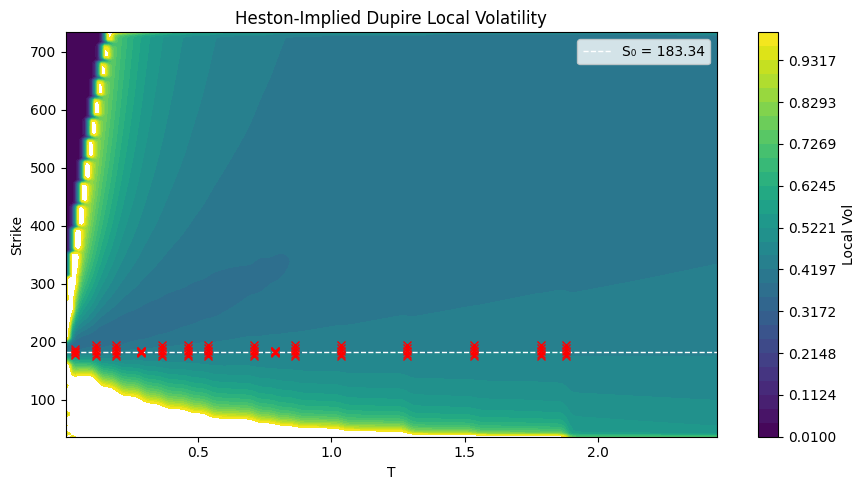

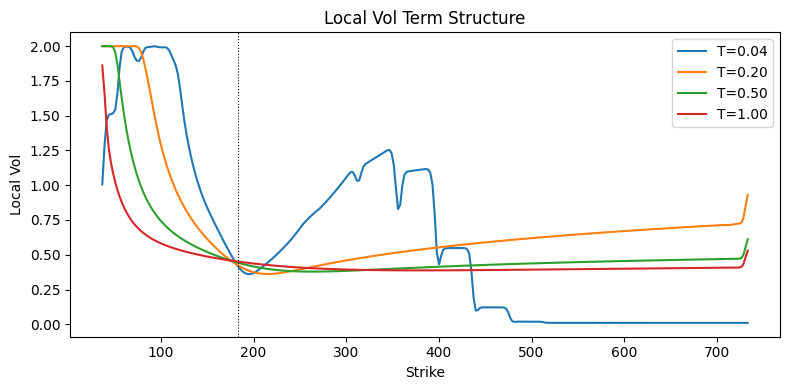

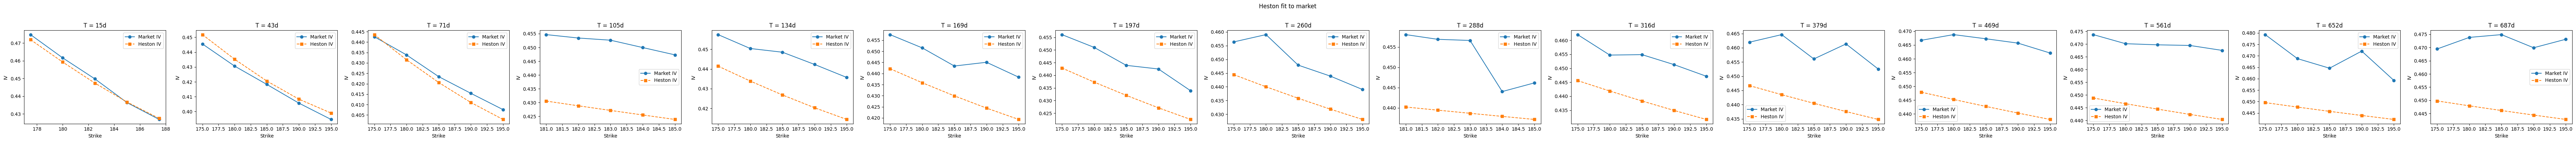

In [10]:
# ---- 4a. Local-vol surface contour ----
fig, ax = plt.subplots(figsize=(9, 5))
TT, KK = np.meshgrid(T_lv, K_lv, indexing='ij')
lvls   = np.linspace(lv_surface.min(), min(lv_surface.max(), 1.0), 30)
cs     = ax.contourf(TT, KK, lv_surface, levels=lvls, cmap='viridis')
plt.colorbar(cs, ax=ax, label='Local Vol')
ax.axhline(S0_nvda, color='w', ls='--', lw=1, label=f'S₀ = {S0_nvda}')
for exp in expiries:
    for K in exp['strikes']:
        ax.plot(exp['T'], K, 'rx', ms=6)
ax.set_xlabel('T');  ax.set_ylabel('Strike')
ax.set_title('Heston-Implied Dupire Local Volatility')
ax.legend(loc='upper right');  plt.tight_layout();  plt.show()

# ---- 4b. Local-vol slice at several maturities ----
fig, ax = plt.subplots(figsize=(8, 4))
for t_slice in [0.04, 0.20, 0.50, 1.0]:
    idx = np.argmin(np.abs(T_lv - t_slice))
    ax.plot(K_lv, lv_surface[idx], label=f'T={T_lv[idx]:.2f}')
ax.axvline(S0_nvda, color='k', ls=':', lw=0.8)
ax.set_xlabel('Strike');  ax.set_ylabel('Local Vol')
ax.set_title('Local Vol Term Structure');  ax.legend();  plt.tight_layout();  plt.show()

# ---- 4c. Heston model IV vs market IV (direct, no SLV) ----
v0_h, kappa_h, theta_h, xi_h, rho_h = heston_params
fig, axes = plt.subplots(1, len(expiries), figsize=(5*len(expiries), 4))
if len(expiries) == 1:
    axes = [axes]
for ax, exp in zip(axes, expiries):
    T = exp['T'];  r = exp['R'];  F = exp['IFwd']
    q = r - np.log(F / S0_nvda) / T if T > 1e-8 else 0.0
    K_arr = np.array(exp['strikes'])
    prices = heston_call_grid(S0_nvda, K_arr, T, r, q,
                              v0_h, kappa_h, theta_h, xi_h, rho_h)
    iv_mod = np.array([blackscholes_impv_scalar(K, T, S0_nvda, float(p),
                       r=r, q=q, callput='call')
                       for K, p in zip(K_arr, prices)])
    ax.plot(K_arr, exp['ivs'], 'o-',  label='Market IV')
    ax.plot(K_arr, iv_mod,     's--', label='Heston IV')
    ax.set_xlabel('Strike');  ax.set_ylabel('IV')
    ax.set_title(f'T = {int(T*365)}d');  ax.legend()
plt.suptitle('Heston fit to market', y=1.02)
plt.tight_layout();  plt.show()

### SLV Smile Calibration Check  (particle method + MC)

SLV smile calibration check

  T = 0.0411  (15d)   max |Δ IV| = 0.0098   ✓
    K=  177.5  mkt=0.4748  SLV=0.4797  err=0.0050
    K=  180.0  mkt=0.4616  SLV=0.4674  err=0.0057
    K=  182.5  mkt=0.4498  SLV=0.4563  err=0.0065
    K=  185.0  mkt=0.4364  SLV=0.4446  err=0.0082
    K=  187.5  mkt=0.4269  SLV=0.4366  err=0.0098


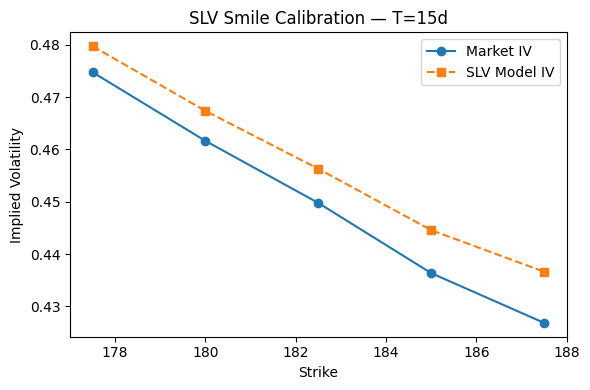


  T = 0.1178  (43d)   max |Δ IV| = 0.0473   !
    K=  175.0  mkt=0.4455  SLV=0.4928  err=0.0473
    K=  180.0  mkt=0.4306  SLV=0.4729  err=0.0423
    K=  185.0  mkt=0.4183  SLV=0.4536  err=0.0353
    K=  190.0  mkt=0.4057  SLV=0.4394  err=0.0337
    K=  195.0  mkt=0.3947  SLV=0.4285  err=0.0338


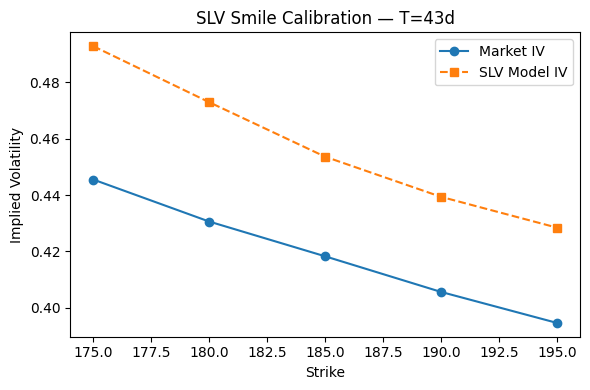


  T = 0.1945  (71d)   max |Δ IV| = 0.0457   !
    K=  175.0  mkt=0.4426  SLV=0.4883  err=0.0457
    K=  180.0  mkt=0.4338  SLV=0.4731  err=0.0392
    K=  185.0  mkt=0.4234  SLV=0.4569  err=0.0335
    K=  190.0  mkt=0.4154  SLV=0.4451  err=0.0297
    K=  195.0  mkt=0.4076  SLV=0.4352  err=0.0276


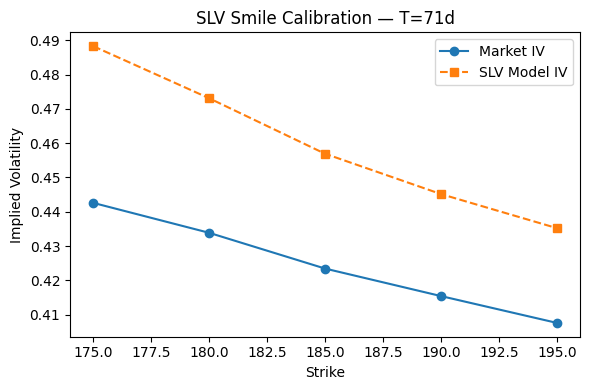

In [11]:
# SLV stochastic-vol parameters — keep your originals;
# the leverage function absorbs the residual.
sigma0_slv   = 0.46
Y0_slv       = 0.0
rho_slv      = -0.50
gamma_slv    = 0.50
kappa_mr_slv = 1.0
N_cal_slv    = 50_000
kappa_bw_slv = 1.0

print("="*60)
print("SLV smile calibration check")
print("="*60)

for exp in expiries:
    T_cal       = exp['T']
    if T_cal * 365 >= 100:
        continue
    r_cal       = exp['R']
    n_steps_cal = max(20, int(100 * T_cal))

    # run particle method with the Heston-based local vol
    _, logS_cal, _ = particle_method(
        S0_nvda, sigma0_slv, Y0_slv, rho_slv, gamma_slv, kappa_mr_slv,
        T_cal, n_steps_cal, N_cal_slv, vol_fn_heston, kappa_bw_slv)
    S_T = np.exp(logS_cal)

    K_list = np.array(exp['strikes'])
    iv_mkt = np.array(exp['ivs'])

    # MC prices → IVs
    call_mc = np.array([np.maximum(S_T - K_, 0).mean() for K_ in K_list])
    put_mc  = np.array([np.maximum(K_ - S_T, 0).mean() for K_ in K_list])
    F_mc    = S_T.mean()

    iv_model = np.array([
        blackscholes_impv_scalar(
            K_, T_cal, S0_nvda, float(p),
            r=0.0, q=0.0,
            callput=('put' if K_ < F_mc else 'call'))
        for K_, p in zip(K_list,
                         np.where(K_list < F_mc, put_mc, call_mc))
    ])

    max_err = np.nanmax(np.abs(iv_model - iv_mkt))
    print(f"\n  T = {T_cal:.4f}  ({int(T_cal*365)}d)   max |Δ IV| = {max_err:.4f}"
          f"   {'✓' if max_err < 0.01 else '!'}")
    for K_, ivm, ivmod in zip(K_list, iv_mkt, iv_model):
        print(f"    K={K_:>7.1f}  mkt={ivm:.4f}  SLV={ivmod:.4f}"
              f"  err={abs(ivmod-ivm):.4f}")

    # plot
    plt.figure(figsize=(6, 4))
    plt.plot(K_list, iv_mkt,   'o-',  label='Market IV')
    plt.plot(K_list, iv_model, 's--', label='SLV Model IV')
    plt.xlabel('Strike');  plt.ylabel('Implied Volatility')
    plt.title(f'SLV Smile Calibration — T={int(T_cal*365)}d')
    plt.legend();  plt.tight_layout();  plt.show()

### American Put Pricing  (LSM lower + BA upper)

In [12]:
T_price        = 15/365
n_steps_price  = 100
N_cal_price    = 50_000
N_ba_price     = 200       # outer paths for BA
N_nested_price = 500       # nested paths for BA
K_puts         = [177.5, 180, 182.5, 185, 187.5]

# use rate from the expiry closest to the pricing horizon
exp_ref = min(expiries, key=lambda e: abs(e['T'] - T_price))
r_price = exp_ref['R']

exercise_idx_p = np.round(np.linspace(0, n_steps_price, 13)).astype(int)
ts_ex_p        = np.linspace(0, T_price, 13)
dt_p           = T_price / n_steps_price

# ---- calibrate leverage function (once) ----
print("Calibrating SLV leverage function …")
lev_store_p, _, _ = particle_method(
    S0_nvda, sigma0_slv, Y0_slv, rho_slv, gamma_slv, kappa_mr_slv,
    T_price, n_steps_price, N_cal_price, vol_fn_heston, kappa_bw_slv)

# quick leverage diagnostic
lev_vals = np.concatenate([lg[1] for lg in lev_store_p])
print(f"  Leverage  min={lev_vals.min():.3f}  mean={lev_vals.mean():.3f}"
      f"  max={lev_vals.max():.3f}")

# ---- generate training paths (for LSM) ----
paths_train_p, Y_train_p = slv_paths_matrix(
    S0_nvda, sigma0_slv, Y0_slv, rho_slv, gamma_slv, kappa_mr_slv,
    T_price, n_steps_price, N_cal_price, lev_store_p,
    exercise_idx_p, seed=42)

print(f"\n{'='*60}")
print(f"American Put Pricing   T={T_price}   r={r_price:.4f}")
print(f"{'='*60}")

for K_put in K_puts:

    # ---- LSM lower bound ----
    price_lsm, policy = ls_pricer(
        paths_train_p, K_put, r_price, ts_ex_p,
        regression_polynomial, degree=3)
    models = policy['models']

    # ---- BA upper bound ----
    paths_ba, Y_ba = slv_paths_matrix(
        S0_nvda, sigma0_slv, Y0_slv, rho_slv, gamma_slv, kappa_mr_slv,
        T_price, n_steps_price, N_ba_price, lev_store_p,
        exercise_idx_p, seed=777)

    exer_fn = lambda S: np.maximum(K_put - S, 0)
    V  = np.full(paths_ba.shape, np.nan)
    EV = np.full(paths_ba.shape, np.nan)
    V[0] = EV[0] = price_lsm

    for i in range(1, len(ts_ex_p) - 1):
        ev  = exer_fn(paths_ba[i])
        ind = exer_or_cont(i, paths_ba[i], models, K_put, r_price, ts_ex_p)
        for j_idx in np.nonzero(ind)[0]:
            V[i, j_idx]  = ev[j_idx] * np.exp(-r_price * ts_ex_p[i])
            EV[i, j_idx] = nested_mc(
                paths_ba[i, j_idx], Y_ba[i, j_idx],
                lev_store_p, exercise_idx_p,
                sigma0_slv, rho_slv, gamma_slv, kappa_mr_slv,
                r_price, 0.0, i, ts_ex_p, N_nested_price,
                models, K_put, dt_p)
        for j_idx in np.nonzero(~ind)[0]:
            val = nested_mc(
                paths_ba[i, j_idx], Y_ba[i, j_idx],
                lev_store_p, exercise_idx_p,
                sigma0_slv, rho_slv, gamma_slv, kappa_mr_slv,
                r_price, 0.0, i, ts_ex_p, N_nested_price,
                models, K_put, dt_p)
            V[i, j_idx]  = val
            EV[i, j_idx] = val

    V[-1]      = exer_fn(paths_ba[-1]) * np.exp(-r_price * ts_ex_p[-1])
    hedges     = np.zeros(paths_ba.shape)
    hedges[1:] = np.cumsum(V[1:] - EV[:-1], axis=0)
    upper      = np.mean(np.amax(
        exer_fn(paths_ba[1:]) * np.exp(-r_price * ts_ex_p[1:, None])
        - hedges[1:], axis=0))

    gap_pct = 100 * (upper - price_lsm) / price_lsm if price_lsm > 0 else np.nan

    print(f"\n  K = {K_put}")
    print(f"    LSM Lower : {price_lsm:.4f}")
    print(f"    BA  Upper : {upper:.4f}")
    print(f"    Gap       : {upper - price_lsm:.4f}  ({gap_pct:.1f}%)")
    print(f"    Valid     : {price_lsm < upper}")

Calibrating SLV leverage function …
  Leverage  min=0.809  mean=2.271  max=4.502

American Put Pricing   T=0.0410958904109589   r=0.0394

  K = 177.5
    LSM Lower : 4.1448
    BA  Upper : 4.4437
    Gap       : 0.2988  (7.2%)
    Valid     : True

  K = 180
    LSM Lower : 4.9724
    BA  Upper : 5.2773
    Gap       : 0.3048  (6.1%)
    Valid     : True

  K = 182.5
    LSM Lower : 5.9664
    BA  Upper : 6.3238
    Gap       : 0.3574  (6.0%)
    Valid     : True

  K = 185
    LSM Lower : 7.1575
    BA  Upper : 7.4705
    Gap       : 0.3130  (4.4%)
    Valid     : True

  K = 187.5
    LSM Lower : 8.5011
    BA  Upper : 8.8382
    Gap       : 0.3371  (4.0%)
    Valid     : True


### European benchmark to cross-check level

In [13]:
# With r = 0 the American premium is ≈ 0 for a put, so the LSM
# price should be close to the BS European price at the flat-vol level.

for K_put in K_puts:
    bs_eur = blackscholes_price(
        K_put, T_price, S0_nvda, np.sqrt(heston_params[0]),
        r=r_price, callput='put')
    print(f"  K={K_put}  BS-European(σ₀)={bs_eur:.4f}")

  K=177.5  BS-European(σ₀)=4.5093
  K=180  BS-European(σ₀)=5.5391
  K=182.5  BS-European(σ₀)=6.7059
  K=185  BS-European(σ₀)=8.0095
  K=187.5  BS-European(σ₀)=9.4469


## Method 1: Single-Expiry Smile Calibration

Method 1 calibrates the SLV leverage function using the IV smile from a single expiry.
For each target expiry, `make_smile_vol_fn` constructs a linear interpolant over the
market strikes and IVs, which is passed as `vol_fn` to the particle method.

Three expiries are tested: 15d, 71d, and 379d. The choice of 379d as the primary
reference is motivated by its proximity to `T_price = 1.0` (365 days) among all
available expiries in the data. Using a closer expiry reduces the mismatch between
the calibrated smile and the actual volatility structure at the pricing horizon.
Shorter expiries (15d, 71d) are included for comparison to assess sensitivity to
the choice of calibration horizon.

In [14]:
from scipy.interpolate import RegularGridInterpolator
from scipy.optimize import minimize

def svi_raw(k, a, b, rho, m, sigma):
    return a + b * (rho * (k - m) + np.sqrt((k - m)**2 + sigma**2))

def fit_svi(strikes, ivs, T, F):
    k = np.log(np.array(strikes) / F)
    w_target = (np.array(ivs)**2) * T
    def obj(params):
        a, b, rho, m, sigma = params
        if b < 0 or sigma < 1e-4 or abs(rho) >= 1:
            return 1e10
        w_model = svi_raw(k, a, b, rho, m, sigma)
        if np.any(w_model <= 0):
            return 1e10
        return np.sum((w_model - w_target)**2)
    best_res = None
    for b0 in [0.1, 0.3]:
        for rho0 in [-0.5, 0.0]:
            x0 = [w_target.mean(), b0, rho0, 0.0, 0.1]
            res = minimize(obj, x0, method='Nelder-Mead',
                           options={'maxiter': 10000, 'xatol': 1e-8, 'fatol': 1e-8})
            if best_res is None or res.fun < best_res.fun:
                best_res = res
    return best_res.x

def build_vol_fn(expiries_list, S0_ref, n_K_fine=150, n_T_fine=80):
    T_nodes = np.array([e['T'] for e in expiries_list])
    K_nodes = np.linspace(S0_ref * 0.5, S0_ref * 2.0, n_K_fine)

    n_ext  = 10
    w_grid = np.zeros((len(T_nodes), n_K_fine))
    for i, exp in enumerate(expiries_list):
        F      = exp['IFwd']
        K_mkt  = np.array(exp['strikes'])
        IV_mkt = np.array(exp['ivs'])
        K_lo, IV_lo = K_mkt[0],  IV_mkt[0]
        K_hi, IV_hi = K_mkt[-1], IV_mkt[-1]
        K_ext_lo    = np.linspace(K_nodes[0], K_lo, n_ext + 1)[:-1]
        K_ext_hi    = np.linspace(K_hi, K_nodes[-1], n_ext + 1)[1:]
        strikes_ext = np.concatenate([K_ext_lo, K_mkt, K_ext_hi])
        ivs_ext     = np.concatenate([np.full(n_ext, IV_lo), IV_mkt, np.full(n_ext, IV_hi)])
        a, b, rho_svi, m, sigma = fit_svi(strikes_ext, ivs_ext, exp['T'], F)
        k_fine = np.log(K_nodes / F)
        w_grid[i] = np.clip(svi_raw(k_fine, a, b, rho_svi, m, sigma), 1e-8, None)

    T_fine = np.linspace(T_nodes.min(), T_nodes.max(), n_T_fine)
    w_interp = RegularGridInterpolator((T_nodes, K_nodes), w_grid,
                                        method='linear', bounds_error=False, fill_value=0.1)
    TT, KK = np.meshgrid(T_fine, K_nodes, indexing='ij')
    w_fine = np.clip(w_interp(np.stack([TT.ravel(), KK.ravel()], axis=1)).reshape(n_T_fine, n_K_fine), 1e-8, None)
    # from scipy.ndimage import gaussian_filter
    # w_fine = gaussian_filter(w_fine, sigma=[0.0, 1.5])
    # w_fine = np.clip(w_fine, 1e-8, None)
    
    """
        Enforce calendar-spread arbitrage-free interpolation
    """
    for j in range(w_fine.shape[1]):
        for i in range(1, w_fine.shape[0]):
            w_fine[i, j] = max(w_fine[i, j], w_fine[i-1, j] + 1e-6)
    
    log_K   = np.log(K_nodes / S0_ref)
    k_grid  = log_K[np.newaxis, :]

    dw_dT   = np.gradient(w_fine, T_fine, axis=0)
    dw_dk   = np.gradient(w_fine, log_K,  axis=1)
    d2w_dk2 = np.gradient(dw_dk,  log_K,  axis=1)

    denom   = (1.0
               - (k_grid / w_fine) * dw_dk
               + 0.25 * (-0.25 - 1.0 / w_fine + k_grid**2 / w_fine**2) * dw_dk**2
               + 0.5 * d2w_dk2)

    loc_var = dw_dT / np.clip(denom, 0.5, None)
    loc_vol = np.sqrt(np.clip(loc_var, 1e-4, 4.0))

    lv_interp = RegularGridInterpolator((T_fine, K_nodes), loc_vol,
                                        method='linear', bounds_error=False, fill_value=0.46)

    # def vol_fn(S, t):
    #     S_arr  = np.atleast_1d(np.asarray(S, dtype=float))
    #     t_clip = float(np.clip(t, T_fine[0], T_fine[-1]))
    #     S_clip = np.clip(S_arr, 175.0, 195.0)
    #     result = lv_interp(np.stack([np.full(len(S_clip), t_clip), S_clip], axis=1))
    #     return np.clip(np.asarray(result, dtype=float), 0.05, 2.0)
    
    """ 
        Remove hard clip and let SVI extrapolate
    """
    def vol_fn(S, t):
        S_arr  = np.atleast_1d(np.asarray(S, dtype=float))
        t_clip = float(np.clip(t, T_fine[0], T_fine[-1]))
        S_clip = np.clip(S_arr, K_nodes[0], K_nodes[-1])  # use the full SVI range
        result = lv_interp(np.stack([np.full(len(S_clip), t_clip), S_clip], axis=1))
        return np.clip(np.asarray(result, dtype=float), 0.05, 2.0)

    return vol_fn

def plot_smile_calibration(expiry, S0_ref, sigma0, Y0, rho, gamma, kappa_mr,
                            n_steps, N_cal, kappa_bw):
    vol_fn = build_vol_fn(expiries, S0_ref)
    r = expiry['R']
    T_cal = expiry['T']
    n_steps_cal = max(10, int(n_steps * T_cal / 1.0))
    _, logS_cal, _ = particle_method(
        S0_ref, sigma0, Y0, rho, gamma, kappa_mr, T_cal,
        n_steps_cal, N_cal, vol_fn, kappa_bw)
    S_T_cal = np.exp(logS_cal)
    K_list = np.array(expiry['strikes'])
    call_mc = np.array([np.maximum(S_T_cal - K_, 0).mean() for K_ in K_list])
    put_mc  = np.array([np.maximum(K_ - S_T_cal, 0).mean() for K_ in K_list])
    put_equiv = np.where(
        K_list >= S0_ref,
        call_mc - S0_ref + K_list * np.exp(-r * T_cal),
        put_mc
    )

    ivs_mc = np.array([
        blackscholes_impv_scalar(K_, T_cal, S0_ref, p, r=r, callput='put')
        for K_, p in zip(K_list, put_equiv)
    ])
    cal_errors = np.abs(ivs_mc - np.array(expiry['ivs']))

    plt.figure(figsize=(6, 4))
    plt.plot(K_list, np.array(expiry['ivs']), 'o-', label='Market IV')
    plt.plot(K_list, ivs_mc, 's--', label='Model IV')
    plt.xlabel('Strike')
    plt.ylabel('Implied Volatility')
    plt.title(f'Smile Calibration — T={int(T_cal*365)}d')
    plt.legend()
    plt.tight_layout()
    plt.show()
    return cal_errors

In [15]:

def run_method1(expiry, cal_errors, S0_nvda, sigma0, Y0, rho, gamma, kappa_mr,
                n_steps, N_cal, N_ba, N_nested, kappa_bw, K_put, T_price):
    vol_fn = build_vol_fn(expiries, S0_nvda)
    r      = expiry['R']

    exercise_indices_m1 = np.round(np.linspace(0, n_steps, 13)).astype(int)
    ts_exercise_m1      = np.linspace(0, T_price, 13)
    dt_m1               = T_price / n_steps

    lev_store_m1, _, _ = particle_method(
        S0_nvda, sigma0, Y0, rho, gamma, kappa_mr, T_price,
        n_steps, N_cal, vol_fn, kappa_bw)

    paths_train_m1, Y_paths_train_m1 = slv_paths_matrix(
        S0_nvda, sigma0, Y0, rho, gamma, kappa_mr, T_price,
        n_steps, N_cal, lev_store_m1, exercise_indices_m1, seed=42)

    price_lsm_m1, policy_m1 = ls_pricer(
        paths_train_m1, K_put, r, ts_exercise_m1, regression_polynomial, degree=3)
    models_m1 = policy_m1['models']

    paths_ba_m1, Y_paths_ba_m1 = slv_paths_matrix(
        S0_nvda, sigma0, Y0, rho, gamma, kappa_mr, T_price,
        n_steps, N_ba, lev_store_m1, exercise_indices_m1, seed=777)

    exer_fn = lambda S: np.maximum(K_put - S, 0)
    V_m1    = np.full(paths_ba_m1.shape, np.nan)
    EV_m1   = np.full(paths_ba_m1.shape, np.nan)
    V_m1[0] = EV_m1[0] = price_lsm_m1

    boundary_hits = 0
    for i in range(1, len(ts_exercise_m1) - 1):
        ev  = exer_fn(paths_ba_m1[i])
        ind = exer_or_cont(i, paths_ba_m1[i], models_m1, K_put, r, ts_exercise_m1)
        for j in np.nonzero(ind)[0]:
            S_j = paths_ba_m1[i, j]
            if S_j < expiry['strikes'][0] or S_j > expiry['strikes'][-1]:
                boundary_hits += 1
            V_m1[i, j]  = ev[j] * np.exp(-r * ts_exercise_m1[i])
            EV_m1[i, j] = nested_mc(S_j, Y_paths_ba_m1[i, j], lev_store_m1,
                                     exercise_indices_m1, sigma0, rho, gamma, kappa_mr,
                                     r, 0.0, i, ts_exercise_m1, N_nested, models_m1, K_put, dt_m1)
        for j in np.nonzero(~ind)[0]:
            S_j = paths_ba_m1[i, j]
            if S_j < expiry['strikes'][0] or S_j > expiry['strikes'][-1]:
                boundary_hits += 1
            V_m1[i, j]  = nested_mc(S_j, Y_paths_ba_m1[i, j], lev_store_m1,
                                     exercise_indices_m1, sigma0, rho, gamma, kappa_mr,
                                     r, 0.0, i, ts_exercise_m1, N_nested, models_m1, K_put, dt_m1)
            EV_m1[i, j] = V_m1[i, j]

    V_m1[-1]      = exer_fn(paths_ba_m1[-1]) * np.exp(-r * ts_exercise_m1[-1])
    hedges_m1     = np.zeros(paths_ba_m1.shape)
    hedges_m1[1:] = np.cumsum(V_m1[1:] - EV_m1[:-1], axis=0)
    upper_m1      = np.mean(np.amax(
        exer_fn(paths_ba_m1[1:]) * np.exp(-r * ts_exercise_m1[1:, np.newaxis]) - hedges_m1[1:],
        axis=0))

    print(f"T={expiry['T']:.4f} ({int(expiry['T']*365)}d) | K={K_put} | r={r:.4f}")
    print(f"  Smile calibration errors:")
    for K_, err in zip(np.array(expiry['strikes']), cal_errors):
        print(f"    K={K_:.1f}  error={err:.4f}")
    print(f"  Max cal error : {cal_errors.max():.4f}")
    print(f"  LSM Lower     : {price_lsm_m1:.4f}")
    print(f"  BA  Upper     : {upper_m1:.4f}")
    print(f"  Sandwich valid: {price_lsm_m1 < upper_m1}")
    print(f"  Boundary hits : {boundary_hits} / {N_ba * (len(ts_exercise_m1)-2)}")
    print()

    return {
        'T': expiry['T'], 'lsm': price_lsm_m1, 'ba': upper_m1,
        'cal_errors': cal_errors, 'boundary_hits': boundary_hits
    }

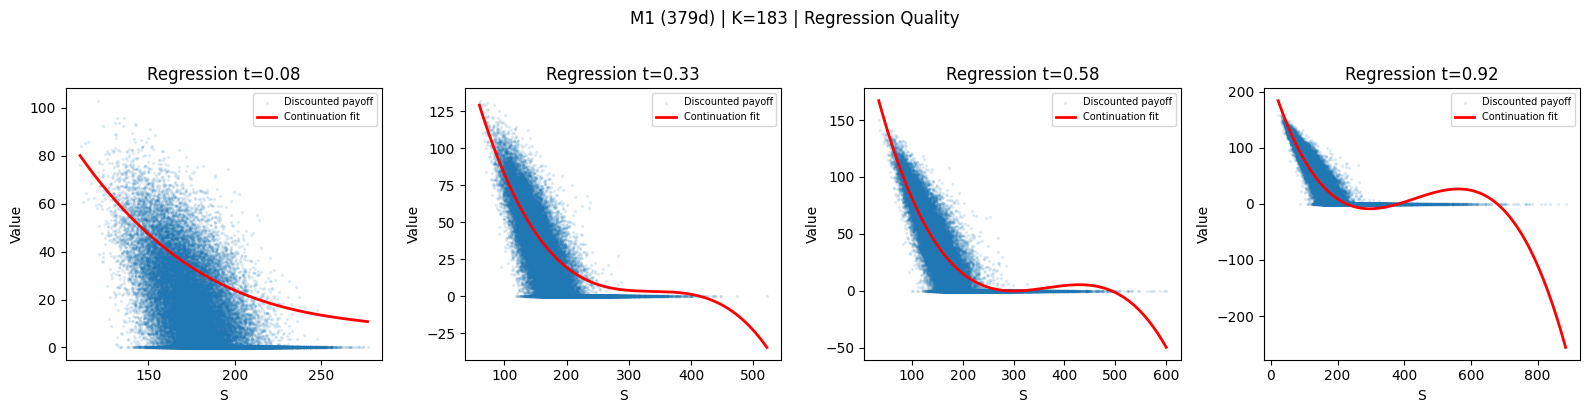

In [16]:
T_price    = 1.0
vol_fn_reg = build_vol_fn(expiries, S0_nvda)

exercise_indices_reg = np.round(np.linspace(0, n_steps, 13)).astype(int)
ts_exercise_reg      = np.linspace(0, T_price, 13)

for target_days in [379]:
    exp_reg = next(e for e in expiries if int(e['T']*365) == target_days)
    r_reg   = exp_reg['R']

    lev_store_reg, _, _ = particle_method(
        S0_nvda, sigma0, Y0, rho, gamma, kappa_mr, T_price,
        n_steps, N_cal, vol_fn_reg, kappa_bw)

    paths_reg, _ = slv_paths_matrix(
        S0_nvda, sigma0, Y0, rho, gamma, kappa_mr, T_price,
        n_steps, N_cal, lev_store_reg, exercise_indices_reg, seed=42)

    _, policy_reg = ls_pricer(
        paths_reg, 183.0, r_reg, ts_exercise_reg, regression_polynomial, degree=3)
    models_reg = policy_reg['models']

    n_plot_times = 4
    time_indices = np.linspace(1, len(ts_exercise_reg) - 2, n_plot_times, dtype=int)
    fig, axes = plt.subplots(1, n_plot_times, figsize=(16, 4))
    for ax, t_idx in zip(axes, time_indices):
        S_t      = paths_reg[t_idx]
        model    = models_reg[t_idx - 1]
        payoff   = np.maximum(183.0 - paths_reg[t_idx + 1], 0)
        S_sort   = np.linspace(S_t.min(), S_t.max(), 200)
        cont_fit = np.polyval(model['coeffs'], S_sort)
        ax.scatter(S_t, payoff, alpha=0.1, s=2, label='Discounted payoff')
        ax.plot(S_sort, cont_fit, 'r-', linewidth=2, label='Continuation fit')
        ax.set_xlabel('S')
        ax.set_ylabel('Value')
        ax.set_title(f'Regression t={ts_exercise_reg[t_idx]:.2f}')
        ax.legend(fontsize=7)
    plt.suptitle(f'M1 ({target_days}d) | K=183 | Regression Quality', y=1.02)
    plt.tight_layout()
    plt.show()

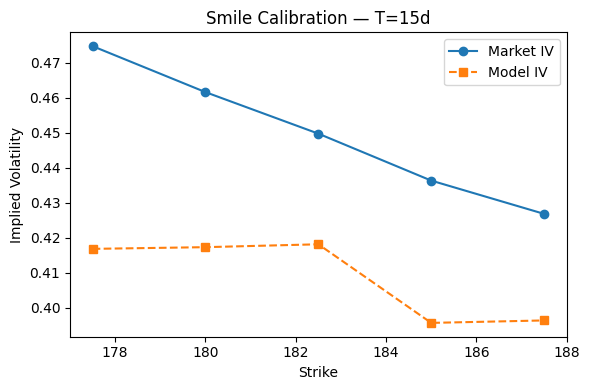

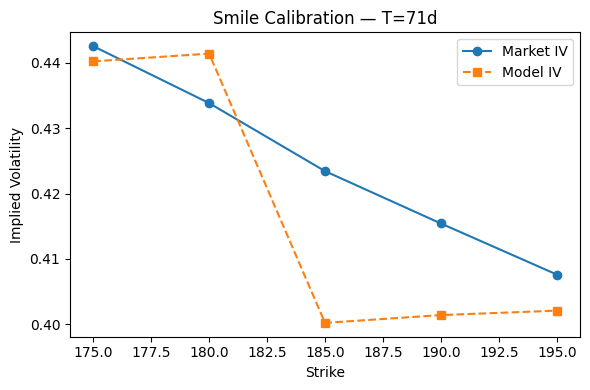

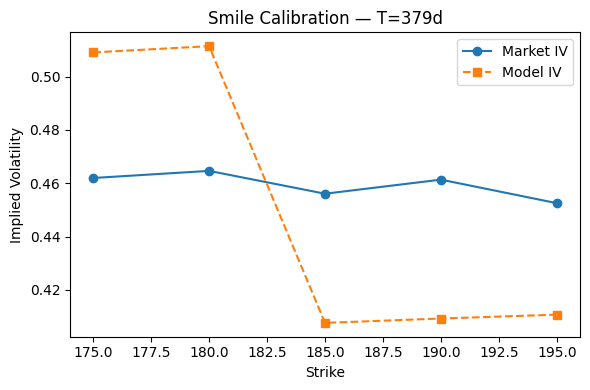

T=0.0411 (15d) | K=175.0 | r=0.0394
  Smile calibration errors:
    K=177.5  error=0.0579
    K=180.0  error=0.0443
    K=182.5  error=0.0316
    K=185.0  error=0.0406
    K=187.5  error=0.0304
  Max cal error : 0.0579
  LSM Lower     : 26.7422
  BA  Upper     : 27.5019
  Sandwich valid: True
  Boundary hits : 2026 / 2200

T=0.1945 (71d) | K=175.0 | r=0.0394
  Smile calibration errors:
    K=175.0  error=0.0023
    K=180.0  error=0.0076
    K=185.0  error=0.0232
    K=190.0  error=0.0140
    K=195.0  error=0.0055
  Max cal error : 0.0232
  LSM Lower     : 26.7422
  BA  Upper     : 27.5230
  Sandwich valid: True
  Boundary hits : 1842 / 2200

T=1.0384 (379d) | K=175.0 | r=0.0378
  Smile calibration errors:
    K=175.0  error=0.0471
    K=180.0  error=0.0468
    K=185.0  error=0.0484
    K=190.0  error=0.0521
    K=195.0  error=0.0418
  Max cal error : 0.0521
  LSM Lower     : 26.7699
  BA  Upper     : 27.5369
  Sandwich valid: True
  Boundary hits : 1842 / 2200

T=0.0411 (15d) | K=183.0

In [17]:
S0_nvda     = 183.34
K_puts      = [175.0, 183.0, 190.0]
T_price     = 1.0
N_ba_m1     = 200
N_nested_m1 = 500

target_days     = [15, 71, 379]
target_expiries = [e for e in expiries if int(e['T']*365) in target_days]

cal_errors_per_expiry = {
    int(exp['T']*365): plot_smile_calibration(
        exp, S0_nvda, sigma0, Y0, rho, gamma, kappa_mr, n_steps, N_cal, kappa_bw)
    for exp in target_expiries
}

results_m1 = []
for K_put in K_puts:
    for exp in target_expiries:
        cal_errors = cal_errors_per_expiry[int(exp['T']*365)]
        res = run_method1(exp, cal_errors, S0_nvda, sigma0, Y0, rho, gamma, kappa_mr,
                          n_steps, N_cal, N_ba_m1, N_nested_m1, kappa_bw, K_put, T_price)
        results_m1.append(res)

## Comparison: Model Prices vs Market Reference

The comparison table reports LSM lower bound and BA upper bound prices across all
methods and strikes (K=175 OTM, K=183 ATM, K=190 ITM).

As a market reference, `P_mkt` is computed as the Black-Scholes European put price
using the IV interpolated from the 379d expiry smile at each strike. This serves as
an approximate benchmark rather than a true American market price — the early exercise
premium is not captured. The `Diff` column reports `P_mkt - LSM`, where a negative
value indicates the model is overpricing relative to the BS European reference.

In [18]:
# exp_ref  = next(e for e in expiries if int(e['T']*365) == 379)
# r_ref    = exp_ref['R']
# p_market = {
#     K: blackscholes_price(
#         K, T_price, S0_nvda,
#         float(np.interp(K, exp_ref['strikes'], exp_ref['ivs'])),
#         r=r_ref, callput='put'
#     )
#     for K in K_puts
# }

# expiry_labels = ['15d', '71d', '379d']

# for K_put in K_puts:
#     moneyness = 'ITM' if K_put > S0_nvda else ('ATM' if K_put == 183.0 else 'OTM')
#     print("=" * 87)
#     print(f"COMPARISON TABLE — NVDA American Put (K={K_put}, T=1.0) [{moneyness}]")
#     print("=" * 87)
#     print(f"{'Method':<20} {'Max Cal Err':>12} {'LSM Lower':>10} {'BA Upper':>10} {'Sandwich':>10} {'Boundary%':>10} {'Diff':>8}")
#     print("-" * 87)

#     k_idx = K_puts.index(K_put)
#     for j, label in enumerate(expiry_labels):
#         res  = results_m1[k_idx * 3 + j]
#         bpct = res['boundary_hits'] / (N_ba_m1 * 11) * 100
#         sand = 'PASS' if res['lsm'] < res['ba'] else 'FAIL'
#         diff = p_market[K_put] - res['lsm']
#         print(f"{'M1 (' + label + ')':<20} {res['cal_errors'].max():>12.4f} {res['lsm']:>10.4f} {res['ba']:>10.4f} {sand:>10} {bpct:>9.1f}% {diff:>+8.4f}")

#     print("-" * 87)
#     print(f"{'P_mkt (BS Eur)':<20} {'—':>12} {p_market[K_put]:>10.4f} {'—':>10} {'—':>10} {'—':>10} {'—':>8}")
#     print("=" * 87)
#     print()

## Parameter Tweaking

To assess the sensitivity of the SLV calibration to model parameters, we perform a
one-at-a-time analysis on `rho` and `gamma`. All other parameters are held fixed at
their baseline values.

- **`rho`** controls the correlation between the asset price and variance process,
  which determines the direction and magnitude of the IV skew.
- **`gamma`** controls the vol-of-vol, which affects the curvature (height) of the IV smile.

Analysis is conducted using Method 1 with the 379d calibration expiry, evaluated at
K=183 (ATM). Calibration error and LSM/BA bounds are reported for each parameter setting.

In [19]:
# def run_m1_light(expiry, rho_val, gamma_val,
#                  S0_ref, sigma0, Y0, kappa_mr,
#                  n_steps, N_cal, N_ba, N_nested, kappa_bw,
#                  K_put, T_price):

#     vol_fn_lt = build_vol_fn(expiries, S0_nvda)
#     r_lt      = expiry['R']
#     T_cal_lt  = expiry['T']

#     n_steps_cal_lt = max(10, int(n_steps * T_cal_lt / 1.0))
#     _, logS_cal_lt, _ = particle_method(
#         S0_ref, sigma0, Y0, rho_val, gamma_val, kappa_mr, T_cal_lt,
#         n_steps_cal_lt, N_cal, vol_fn_lt, kappa_bw)
#     S_T_cal_lt  = np.exp(logS_cal_lt)
#     K_list_lt   = np.array(expiry['strikes'])
#     call_mc_lt  = np.array([np.maximum(S_T_cal_lt - K_, 0).mean() for K_ in K_list_lt])
#     put_mc_lt   = np.array([np.maximum(K_ - S_T_cal_lt, 0).mean() for K_ in K_list_lt])
#     put_equiv_mc_lt = np.where(
#         K_list_lt >= S0_ref,
#         call_mc_lt - S0_ref + K_list_lt * np.exp(-r_lt * T_cal_lt),
#         put_mc_lt
#     )
#     ivs_mc_lt = np.array([
#         blackscholes_impv_scalar(K_, T_cal_lt, S0_ref, p, r=r_lt, callput='put')
#         for K_, p in zip(K_list_lt, put_equiv_mc_lt)
#     ])
#     max_cal_err_lt = np.abs(ivs_mc_lt - np.array(expiry['ivs'])).max()

#     exercise_indices_lt = np.round(np.linspace(0, n_steps, 13)).astype(int)
#     ts_exercise_lt      = np.linspace(0, T_price, 13)
#     dt_lt               = T_price / n_steps

#     lev_store_lt, _, _ = particle_method(
#         S0_ref, sigma0, Y0, rho_val, gamma_val, kappa_mr, T_price,
#         n_steps, N_cal, vol_fn_lt, kappa_bw)

#     paths_train_lt, Y_paths_train_lt = slv_paths_matrix(
#         S0_ref, sigma0, Y0, rho_val, gamma_val, kappa_mr, T_price,
#         n_steps, N_cal, lev_store_lt, exercise_indices_lt, seed=42)

#     price_lsm_lt, policy_lt = ls_pricer(
#         paths_train_lt, K_put, r_lt, ts_exercise_lt, regression_polynomial, degree=3)
#     models_lt = policy_lt['models']

#     paths_ba_lt, Y_paths_ba_lt = slv_paths_matrix(
#         S0_ref, sigma0, Y0, rho_val, gamma_val, kappa_mr, T_price,
#         n_steps, N_ba, lev_store_lt, exercise_indices_lt, seed=777)

#     exer_fn_lt = lambda S: np.maximum(K_put - S, 0)
#     V_lt       = np.full(paths_ba_lt.shape, np.nan)
#     EV_lt      = np.full(paths_ba_lt.shape, np.nan)
#     V_lt[0]    = EV_lt[0] = price_lsm_lt

#     for i in range(1, len(ts_exercise_lt) - 1):
#         ev_lt  = exer_fn_lt(paths_ba_lt[i])
#         ind_lt = exer_or_cont(i, paths_ba_lt[i], models_lt, K_put, r_lt, ts_exercise_lt)
#         for j in np.nonzero(ind_lt)[0]:
#             V_lt[i, j]  = ev_lt[j] * np.exp(-r_lt * ts_exercise_lt[i])
#             EV_lt[i, j] = nested_mc(
#                 paths_ba_lt[i, j], Y_paths_ba_lt[i, j], lev_store_lt,
#                 exercise_indices_lt, sigma0, rho_val, gamma_val, kappa_mr,
#                 r_lt, 0.0, i, ts_exercise_lt, N_nested, models_lt, K_put, dt_lt)
#         for j in np.nonzero(~ind_lt)[0]:
#             V_lt[i, j]  = nested_mc(
#                 paths_ba_lt[i, j], Y_paths_ba_lt[i, j], lev_store_lt,
#                 exercise_indices_lt, sigma0, rho_val, gamma_val, kappa_mr,
#                 r_lt, 0.0, i, ts_exercise_lt, N_nested, models_lt, K_put, dt_lt)
#             EV_lt[i, j] = V_lt[i, j]

#     V_lt[-1]       = exer_fn_lt(paths_ba_lt[-1]) * np.exp(-r_lt * ts_exercise_lt[-1])
#     hedges_lt      = np.zeros(paths_ba_lt.shape)
#     hedges_lt[1:]  = np.cumsum(V_lt[1:] - EV_lt[:-1], axis=0)
#     upper_lt       = np.mean(np.amax(
#         exer_fn_lt(paths_ba_lt[1:]) * np.exp(-r_lt * ts_exercise_lt[1:, np.newaxis])
#         - hedges_lt[1:], axis=0))

#     return {'max_cal_err': max_cal_err_lt, 'lsm': price_lsm_lt, 'ba': upper_lt}

In [20]:
# exp_379_lt = next(e for e in expiries if int(e['T'] * 365) == 379)
# K_tweak    = 183.0
# N_ba_tw    = 200
# N_nested_tw = 500

# rho_vals   = [-0.30, -0.50, -0.70]
# gamma_vals = [0.30,   0.50,  0.70]

# baseline_lt = run_m1_light(
#     exp_379_lt, -0.50, 0.50,
#     S0_nvda, sigma0, Y0, kappa_mr,
#     n_steps, N_cal, N_ba_tw, N_nested_tw, kappa_bw,
#     K_tweak, T_price)
    
# sweep_rho   = []
# for rho_tw in rho_vals:
#     if rho_tw == -0.50:
#         sweep_rho.append({'rho': rho_tw, **baseline_lt})
#     else:
#         res = run_m1_light(
#             exp_379_lt, rho_tw, 0.50,
#             S0_nvda, sigma0, Y0, kappa_mr,
#             n_steps, N_cal, N_ba_tw, N_nested_tw, kappa_bw,
#             K_tweak, T_price)
#         sweep_rho.append({'rho': rho_tw, **res})

# sweep_gamma = []
# for gamma_tw in gamma_vals:
#     if gamma_tw == 0.50:
#         sweep_gamma.append({'gamma': gamma_tw, **baseline_lt})
#     else:
#         res = run_m1_light(
#             exp_379_lt, -0.50, gamma_tw,
#             S0_nvda, sigma0, Y0, kappa_mr,
#             n_steps, N_cal, N_ba_tw, N_nested_tw, kappa_bw,
#             K_tweak, T_price)
#         sweep_gamma.append({'gamma': gamma_tw, **res})

In [21]:
# print("=" * 65)
# print(f"PARAMETER TWEAKING — M1 (379d) | K={K_tweak} | gamma=0.50 fixed")
# print("=" * 65)
# print(f"{'rho':>8} {'Max Cal Err':>12} {'LSM Lower':>10} {'BA Upper':>10} {'Sandwich':>10}")
# print("-" * 65)
# for row in sweep_rho:
#     sand = 'PASS' if row['lsm'] < row['ba'] else 'FAIL'
#     base = ' ← baseline' if row['rho'] == -0.50 else ''
#     print(f"{row['rho']:>8.2f} {row['max_cal_err']:>12.4f} {row['lsm']:>10.4f} {row['ba']:>10.4f} {sand:>10}{base}")
# print("=" * 65)

# print()

# print("=" * 65)
# print(f"PARAMETER TWEAKING — M1 (379d) | K={K_tweak} | rho=-0.50 fixed")
# print("=" * 65)
# print(f"{'gamma':>8} {'Max Cal Err':>12} {'LSM Lower':>10} {'BA Upper':>10} {'Sandwich':>10}")
# print("-" * 65)
# for row in sweep_gamma:
#     sand = 'PASS' if row['lsm'] < row['ba'] else 'FAIL'
#     base = ' ← baseline' if row['gamma'] == 0.50 else ''
#     print(f"{row['gamma']:>8.2f} {row['max_cal_err']:>12.4f} {row['lsm']:>10.4f} {row['ba']:>10.4f} {sand:>10}{base}")
# print("=" * 65)

In [22]:
# lev_store_test, logS_test, _ = particle_method(
#     S0_nvda, sigma0, Y0, rho, gamma, kappa_mr, T_price,
#     n_steps, N_cal, vol_fn_reg, kappa_bw)

# S_T = np.exp(logS_test)

# print(f"S0       : {S0_nvda}")
# print(f"mean(S_T): {S_T.mean():.2f}")
# print(f"std(S_T) : {S_T.std():.2f}")
# print(f"min(S_T) : {S_T.min():.2f}")
# print(f"max(S_T) : {S_T.max():.2f}")
# print(f"p1       : {np.percentile(S_T, 1):.2f}")
# print(f"p5       : {np.percentile(S_T, 5):.2f}")
# print(f"p50      : {np.percentile(S_T, 50):.2f}")
# print(f"p95      : {np.percentile(S_T, 95):.2f}")
# print(f"p99      : {np.percentile(S_T, 99):.2f}")
# print(f"S_T > 400: {(S_T > 400).mean()*100:.2f}%")
# print(f"S_T > 600: {(S_T > 600).mean()*100:.2f}%")
# print(f"S_T > 800: {(S_T > 800).mean()*100:.2f}%")

# import scipy.stats as stats
# sigma_eff = sigma0
# bs_mean = S0_nvda * np.exp(0.5 * sigma_eff**2 * T_price)
# bs_std  = S0_nvda * np.exp(0.5 * sigma_eff**2 * T_price) * np.sqrt(np.exp(sigma_eff**2 * T_price) - 1)
# print(f"\nBS log-normal 이론값 (sigma={sigma_eff}):")
# print(f"  mean: {bs_mean:.2f}")
# print(f"  std : {bs_std:.2f}")
# print(f"  p99 : {stats.lognorm.ppf(0.99, s=sigma_eff*np.sqrt(T_price), scale=S0_nvda):.2f}")